# Linear and Logistic Regression — the complete picture

**Where this sits.** These two models are the foundation everything else is built on. A neuron *is* logistic regression; a neural network is many of them stacked. Understanding these two properly means understanding loss functions, gradients, regularization, overfitting, and evaluation — every idea that reappears later, in its simplest possible form.

They are also, quietly, the models most used in the real world: interpretable, fast, hard to break, and often within a percent of a gradient-boosted forest on tabular data.

**What this notebook covers**

| Part | Topic |
|---|---|
| 1 | Linear regression: the model, the loss, two ways to solve it, from scratch |
| 2 | Evaluating a regressor, and the assumptions you are silently making |
| 3 | Logistic regression: from linear to probabilities, from scratch |
| 4 | Evaluating a classifier properly (accuracy is not enough) |
| 5 | Regularization: Ridge, Lasso, Elastic Net |
| 6 | The same models with scikit-learn — and pipelines done right |
| 7 | Preprocessing: scaling, missing values, categories, outliers, leakage |
| 8 | Feature engineering: the part that actually wins |
| 9 | **Six challenge problems** where the naive model fails and a technique fixes it |
| 10 | A working checklist, exercises, and resources |

Parts 1–4 are the theory. Parts 7–9 are where the accuracy comes from.

## 0. Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

RED, BLUE, GREEN, PURPLE = "#e05252", "#3a7ddc", "#2fa84f", "#7a4fbf"

import sklearn
print("numpy", np.__version__, "| pandas", pd.__version__, "| sklearn", sklearn.__version__)

numpy 2.5.1 | pandas 3.0.5 | sklearn 1.9.0


---

# Part 1 — Linear regression

## 1.1 The model

We assume the target is a **weighted sum of the features**, plus a constant:

$$\hat{y} = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b = \mathbf{w}^\top \mathbf{x} + b$$

* $x_j$ — the features (also: inputs, predictors, independent variables)
* $w_j$ — the weights (also: coefficients, $\beta$). **This is what we learn.**
* $b$ — the bias (also: intercept). The prediction when all features are zero.
* $\hat{y}$ — the prediction, a continuous number

Each weight has a direct, useful interpretation:

> $w_j$ is the change in $\hat y$ when $x_j$ increases by one unit **and every other feature stays fixed**.

That "everything else fixed" clause is what makes regression coefficients different from simple correlations, and it is the source of most misreadings of regression output.

### The bias trick

Carrying $b$ separately clutters every formula. Instead we prepend a column of ones to $X$ and treat the bias as just another weight:

$$
X = \begin{bmatrix} 1 & x_{11} & \cdots & x_{1n} \\ \vdots & & & \vdots \\ 1 & x_{m1} & \cdots & x_{mn}\end{bmatrix},
\qquad \hat{\mathbf{y}} = X\mathbf{w}
$$

Now the whole model is one matrix multiplication.

In [6]:
def add_bias(X):
    """Prepend a column of ones so the intercept is learned like any other weight."""
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    return np.hstack([np.ones((X.shape[0], 1)), X])


# a tiny example: predict price from area
area = np.array([50, 80, 120, 160, 200], dtype=float)
price = np.array([120, 175, 250, 320, 390], dtype=float)

Xb = add_bias(area)
w_demo = np.array([20.0, 1.9])        # b = 20, w = 1.9   (guessed, not learned yet)

print("design matrix X (with the bias column):\n", Xb)
print("\nweights w:", w_demo)
print("predictions X @ w:", Xb @ w_demo)
print("actual y        :", price)

design matrix X (with the bias column):
 [[  1.  50.]
 [  1.  80.]
 [  1. 120.]
 [  1. 160.]
 [  1. 200.]]

weights w: [20.   1.9]
predictions X @ w: [115. 172. 248. 324. 400.]
actual y        : [120. 175. 250. 320. 390.]


## 1.2 The loss function

To *learn* the weights we need a number saying how wrong they are. The standard choice is **mean squared error**:

$$\mathcal{L}(\mathbf{w}) = \frac{1}{m}\sum_{i=1}^{m}\left(\hat{y}_i - y_i\right)^2 = \frac{1}{m}\|X\mathbf{w} - \mathbf{y}\|^2$$

Why squared, rather than absolute error?

* **It is differentiable everywhere**, so we can take gradients. $|x|$ has a corner at 0.
* **It punishes large errors disproportionately.** Being off by 10 is 100 times worse than being off by 1, not 10 times.
* **It has a unique closed-form minimum.** The loss is a convex parabola in $\mathbf{w}$ — one valley, no local minima, no initialization worries.
* **It is the maximum-likelihood estimate** if you assume the noise is Gaussian, which is often a reasonable model of "many small independent effects added together".

The main downside is the flip side of the second point: MSE is **very sensitive to outliers**. One badly wrong data point can dominate the whole sum. Alternatives are MAE (absolute error) and the Huber loss, which is quadratic near zero and linear far away.

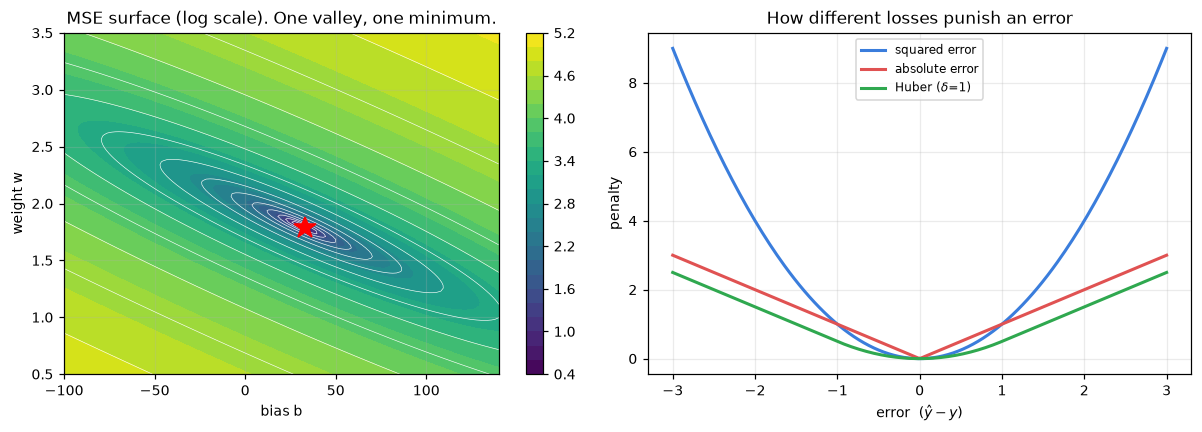

In [7]:
def mse(y, y_hat):
    return float(np.mean((y_hat - y) ** 2))

# the loss surface for a one-feature model, over a grid of (b, w)
bs = np.linspace(-100, 140, 120)
ws = np.linspace(0.5, 3.5, 120)
BB, WW = np.meshgrid(bs, ws)
Z = np.array([[mse(price, add_bias(area) @ np.array([b, w])) for b in bs] for w in ws])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cs = axes[0].contourf(BB, WW, np.log10(Z), levels=25, cmap="viridis")
axes[0].contour(BB, WW, np.log10(Z), levels=15, colors="white", linewidths=0.4)
i, j = np.unravel_index(Z.argmin(), Z.shape)
axes[0].plot(bs[j], ws[i], "r*", ms=15)
axes[0].set_xlabel("bias b"); axes[0].set_ylabel("weight w")
axes[0].set_title("MSE surface (log scale). One valley, one minimum.")
plt.colorbar(cs, ax=axes[0])

e = np.linspace(-3, 3, 200)
axes[1].plot(e, e ** 2, color=BLUE, lw=2, label="squared error")
axes[1].plot(e, np.abs(e), color=RED, lw=2, label="absolute error")
axes[1].plot(e, np.where(np.abs(e) <= 1, 0.5 * e ** 2, np.abs(e) - 0.5),
             color=GREEN, lw=2, label="Huber ($\\delta$=1)")
axes[1].set_xlabel("error  ($\\hat{y} - y$)"); axes[1].set_ylabel("penalty")
axes[1].set_title("How different losses punish an error"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 1.3 Solution 1: the normal equation (closed form)

Because the loss is a convex quadratic, we can find the minimum exactly by setting the gradient to zero. Write the loss as

$$\mathcal{L} = \frac{1}{m}(X\mathbf{w} - \mathbf{y})^\top(X\mathbf{w} - \mathbf{y})$$

Differentiate with respect to $\mathbf{w}$ (using $\frac{\partial}{\partial \mathbf w}\mathbf{w}^\top A \mathbf{w} = 2A\mathbf{w}$ for symmetric $A$):

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \frac{2}{m}X^\top(X\mathbf{w} - \mathbf{y}) = 0
\quad\Longrightarrow\quad X^\top X \mathbf{w} = X^\top \mathbf{y}$$

$$\boxed{\;\mathbf{w}^* = (X^\top X)^{-1} X^\top \mathbf{y}\;}$$

No iterations, no learning rate, no initialization. Exact.

**When you cannot use it:**

* $X^\top X$ must be invertible. It is not if two features are perfectly correlated, or if you have more features than samples ($n > m$). Ridge regression (Part 5) fixes exactly this.
* It costs $O(n^3)$ to invert an $n \times n$ matrix, so it is impractical beyond roughly 10,000 features.
* It only exists because MSE is quadratic. Change the loss — as logistic regression does — and there is no closed form at all.

In practice, never call `np.linalg.inv`. Use `np.linalg.lstsq`, which solves the system by QR/SVD decomposition: more accurate, and it handles singular matrices gracefully.

In [8]:
def fit_normal_equation(X, y, use_inv=False):
    """Closed-form least squares. Returns w, where w[0] is the intercept."""
    Xb = add_bias(X)
    if use_inv:                                       # the textbook formula (don't do this)
        return np.linalg.inv(Xb.T @ Xb) @ Xb.T @ y
    w, *_ = np.linalg.lstsq(Xb, y, rcond=None)        # numerically stable version
    return w


w_star = fit_normal_equation(area, price)
print(f"learned model: price = {w_star[0]:.2f} + {w_star[1]:.3f} * area")
print(f"MSE at the optimum: {mse(price, add_bias(area) @ w_star):.3f}")

# a degenerate case: a perfectly duplicated feature
X_dup = np.c_[area, area * 2]
try:
    bad = np.linalg.inv(add_bias(X_dup).T @ add_bias(X_dup))
    print("\ninv() succeeded, but look at the magnitudes:", np.abs(bad).max())
except np.linalg.LinAlgError as e:
    print("\ninv() failed:", e)
print("lstsq() handles it:", np.round(fit_normal_equation(X_dup, price), 3))
print("-> it returns the minimum-norm solution instead of blowing up.")

learned model: price = 31.18 + 1.802 * area
MSE at the optimum: 2.231

inv() failed: Singular matrix
lstsq() handles it: [31.181  0.36   0.721]
-> it returns the minimum-norm solution instead of blowing up.


## 1.4 Solution 2: gradient descent

The method that generalizes to everything else. Start anywhere, then repeatedly step against the gradient:

$$\mathbf{w} \leftarrow \mathbf{w} - \alpha \, \nabla_{\mathbf{w}} \mathcal{L}, \qquad
\nabla_{\mathbf{w}} \mathcal{L} = \frac{2}{m} X^\top (X\mathbf{w} - \mathbf{y})$$

$\alpha$ is the **learning rate**. Too small and it crawls; too large and it diverges.

Three variants, differing only in how much data each step uses:

| Variant | Samples per step | Character |
|---|---|---|
| Batch | all $m$ | smooth, expensive |
| **Mini-batch** | 32–512 | the standard compromise |
| Stochastic (SGD) | 1 | noisy, very cheap steps |

**Feature scaling matters enormously here.** If one feature ranges over $[0, 1]$ and another over $[0, 10^6]$, the loss surface becomes a long thin ravine and gradient descent zig-zags down it. We demonstrate this in Part 7.

In [9]:
def fit_gradient_descent(X, y, lr=0.01, epochs=500, batch_size=None, seed=0, record=False):
    """Mini-batch gradient descent for linear regression."""
    Xb = add_bias(X)
    m, n = Xb.shape
    w = np.zeros(n)
    batch_size = batch_size or m
    rng = np.random.default_rng(seed)
    history = {"loss": [], "w": []}

    for ep in range(epochs):
        idx = rng.permutation(m)
        for s in range(0, m, batch_size):
            b = idx[s:s + batch_size]
            resid = Xb[b] @ w - y[b]                       # forward + error
            grad = 2 / len(b) * (Xb[b].T @ resid)          # gradient
            w -= lr * grad                                 # update
        if record:
            history["loss"].append(mse(y, Xb @ w))
            history["w"].append(w.copy())
    return (w, history) if record else w


# standardize first, or gradient descent on raw 'area' values will explode
area_s = (area - area.mean()) / area.std()
price_s = (price - price.mean()) / price.std()

w_gd, hist = fit_gradient_descent(area_s, price_s, lr=0.05, epochs=300, record=True)

# convert the standardized weights back to the original units
w1 = w_gd[1] * price.std() / area.std()
w0 = price.mean() + price.std() * w_gd[0] - w1 * area.mean()

print(f"normal equation : price = {w_star[0]:8.3f} + {w_star[1]:.4f} * area")
print(f"gradient descent: price = {w0:8.3f} + {w1:.4f} * area")
print("\nSame answer, reached two completely different ways.")

normal equation : price =   31.181 + 1.8018 * area
gradient descent: price =   31.181 + 1.8018 * area

Same answer, reached two completely different ways.


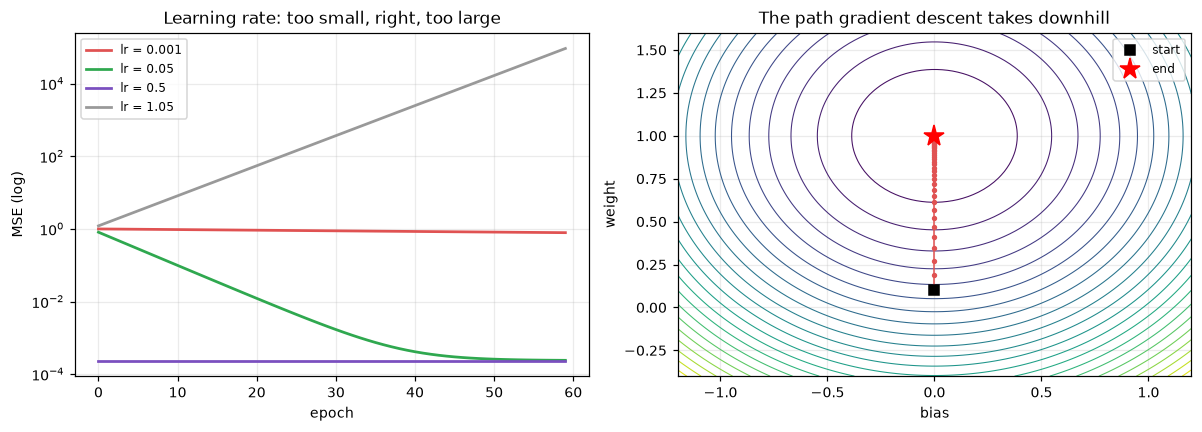

In [10]:
# what the learning rate does
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for lr, color in [(0.001, RED), (0.05, GREEN), (0.5, PURPLE), (1.05, "#999")]:
    _, h = fit_gradient_descent(area_s, price_s, lr=lr, epochs=60, record=True)
    axes[0].plot(h["loss"], color=color, lw=1.8, label=f"lr = {lr}")
axes[0].set_yscale("log"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE (log)")
axes[0].set_title("Learning rate: too small, right, too large"); axes[0].legend(fontsize=8)

# the path taken across the loss surface
bs2 = np.linspace(-1.2, 1.2, 100); ws2 = np.linspace(-0.4, 1.6, 100)
BB2, WW2 = np.meshgrid(bs2, ws2)
Z2 = np.array([[mse(price_s, add_bias(area_s) @ np.array([b, w])) for b in bs2] for w in ws2])
axes[1].contour(BB2, WW2, Z2, levels=25, cmap="viridis", linewidths=0.7)
P = np.array(hist["w"])
axes[1].plot(P[:, 0], P[:, 1], "-o", color=RED, ms=2.5, lw=1)
axes[1].plot(P[0, 0], P[0, 1], "ks", ms=7, label="start")
axes[1].plot(P[-1, 0], P[-1, 1], "r*", ms=14, label="end")
axes[1].set_xlabel("bias"); axes[1].set_ylabel("weight"); axes[1].legend(fontsize=8)
axes[1].set_title("The path gradient descent takes downhill")
plt.tight_layout(); plt.show()

---

# Part 2 — Evaluating a regressor, and what you are assuming

## 2.1 Metrics

| Metric | Formula | Reads as |
|---|---|---|
| **MSE** | $\displaystyle \frac{1}{m}\sum_{i=1}^{m}(\hat y_i - y_i)^2$ | average squared error. Units are $y^2$, so hard to interpret |
| **RMSE** | $\displaystyle \sqrt{\text{MSE}}$ | same units as $y$. "Typically off by this much" |
| **MAE** | $\displaystyle \frac{1}{m}\sum_{i=1}^{m}\lvert\hat y_i - y_i\rvert$ | median-ish error, robust to outliers |
| **$R^2$** | $\displaystyle 1 - \frac{\sum_{i=1}^{m}(\hat y_i - y_i)^2}{\sum_{i=1}^{m}(\bar y - y_i)^2}$ | fraction of variance explained; 0 = no better than predicting the mean |
| **MAPE** | $\displaystyle \frac{100}{m}\sum_{i=1}^{m}\left\lvert\frac{\hat y_i - y_i}{y_i}\right\rvert$ | percentage error; breaks when $y_i \approx 0$ |

Two warnings worth internalizing:

**$R^2$ never decreases when you add a feature** — even a column of pure noise. That is why *adjusted* $R^2$ exists, and why you must always compute $R^2$ on **held-out data**, never on the training set.

**A high $R^2$ does not mean the model is right.** We saw this in the first session: a straight line through curved data can score 0.95 while being systematically wrong at both ends. Always look at the residuals.

In [11]:
def regression_metrics(y, y_hat):
    y, y_hat = np.asarray(y, float), np.asarray(y_hat, float)
    resid = y_hat - y
    ss_res = np.sum(resid ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return {
        "MSE": ss_res / len(y),
        "RMSE": np.sqrt(ss_res / len(y)),
        "MAE": np.mean(np.abs(resid)),
        "R2": 1 - ss_res / ss_tot,
    }


def adjusted_r2(r2, m, n_features):
    return 1 - (1 - r2) * (m - 1) / (m - n_features - 1)


# demonstrate that R^2 rises even with pure noise features
rng = np.random.default_rng(0)
m = 60
x_real = rng.normal(size=(m, 1))
y_toy = 3 * x_real[:, 0] + rng.normal(0, 1, m)

print(f"{'noise features added':>21} | {'R2':>7} | {'adjusted R2':>12}")
print("-" * 48)
for k in [0, 5, 20, 45]:
    X_aug = np.hstack([x_real, rng.normal(size=(m, k))]) if k else x_real
    w = fit_normal_equation(X_aug, y_toy)
    r2 = regression_metrics(y_toy, add_bias(X_aug) @ w)["R2"]
    print(f"{k:>21} | {r2:>7.3f} | {adjusted_r2(r2, m, X_aug.shape[1]):>12.3f}")

print("\nR2 climbs towards 1.0 with meaningless columns. Adjusted R2 punishes them.")
print("The real defence is a held-out test set.")

 noise features added |      R2 |  adjusted R2
------------------------------------------------
                    0 |   0.868 |        0.866
                    5 |   0.871 |        0.857
                   20 |   0.898 |        0.842
                   45 |   0.968 |        0.853

R2 climbs towards 1.0 with meaningless columns. Adjusted R2 punishes them.
The real defence is a held-out test set.


## 2.2 The assumptions behind linear regression

Ordinary least squares is not assumption-free. You do not have to satisfy all of these to get a useful model, but you should know which one you are violating and what it costs you.

| Assumption | What it means | If violated |
|---|---|---|
| **Linearity** | $y$ is a linear function of the features | biased predictions; fix with feature engineering (Part 8) |
| **Independence** | samples are independent | wrong confidence intervals (common with time series) |
| **Homoscedasticity** | error variance is constant across $\hat y$ | coefficients still unbiased, but uncertainty estimates are wrong; often fixed by transforming $y$ |
| **No multicollinearity** | features are not near-duplicates | coefficients become huge, unstable and uninterpretable; fix with Ridge |
| **Normal residuals** | errors are roughly Gaussian | only matters for p-values and intervals, not for prediction |
| **No influential outliers** | no single point dominates | one point can swing the whole fit |

The diagnostic tool is one plot: **residuals against predictions**. If the model is right, it should look like a formless cloud around zero.

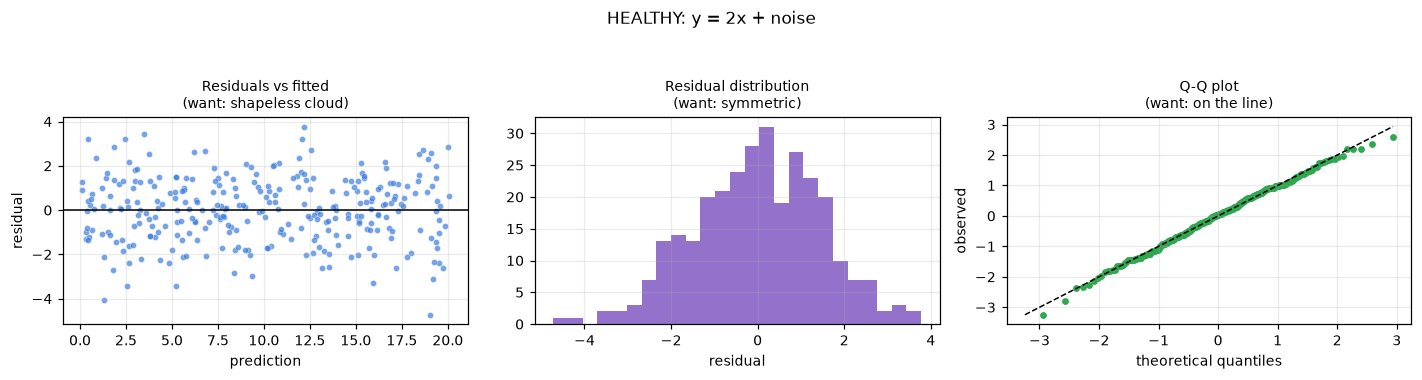

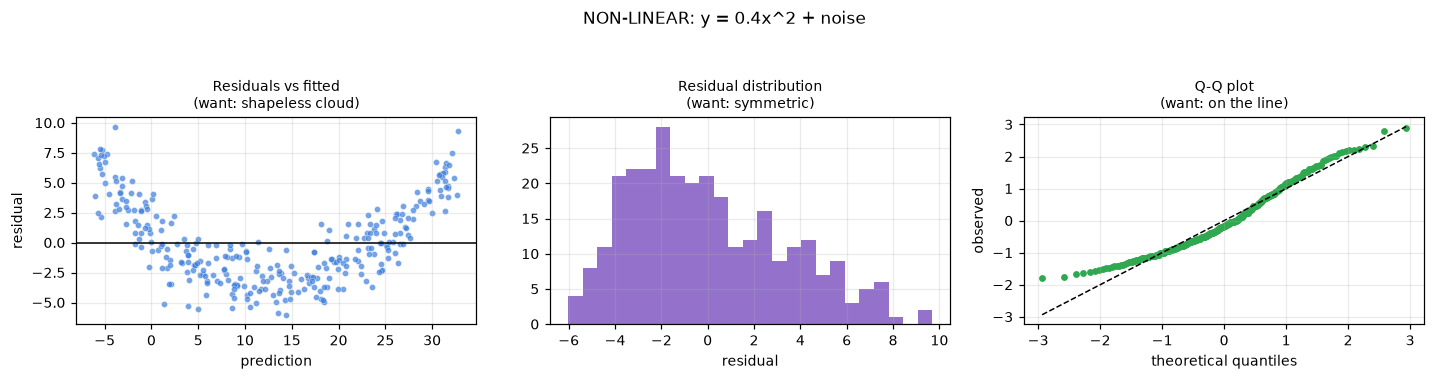

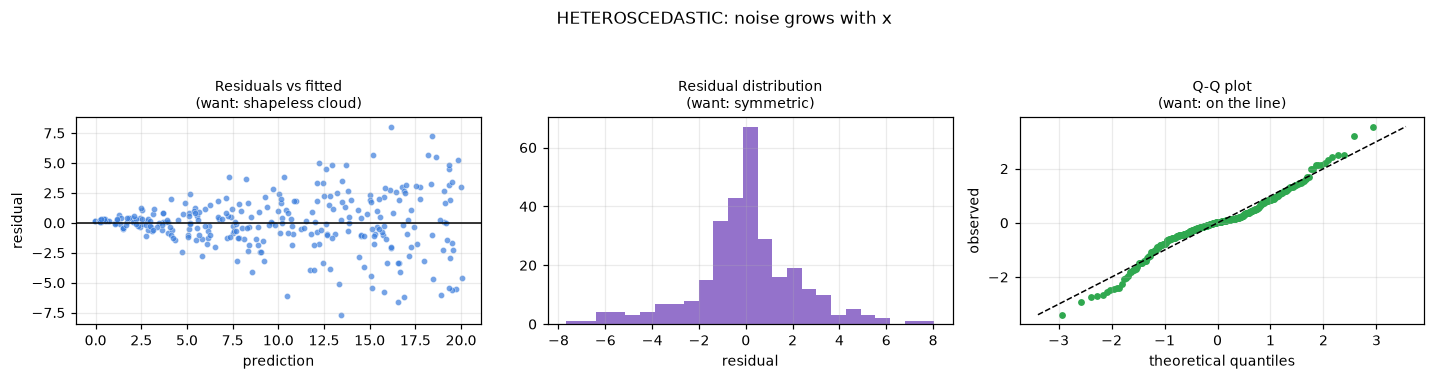

In [12]:
def residual_plots(y, y_hat, title=""):
    resid = y - y_hat
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))

    axes[0].scatter(y_hat, resid, s=16, alpha=0.7, color=BLUE, edgecolor="w", linewidth=0.3)
    axes[0].axhline(0, color="k", lw=1)
    axes[0].set_xlabel("prediction"); axes[0].set_ylabel("residual")
    axes[0].set_title("Residuals vs fitted\n(want: shapeless cloud)", fontsize=9)

    axes[1].hist(resid, bins=25, color=PURPLE, alpha=0.8)
    axes[1].set_xlabel("residual"); axes[1].set_title("Residual distribution\n(want: symmetric)", fontsize=9)

    # Q-Q plot against a normal distribution, computed by hand
    s = np.sort((resid - resid.mean()) / (resid.std() + 1e-12))
    q = np.linspace(0.5 / len(s), 1 - 0.5 / len(s), len(s))
    from scipy.stats import norm
    axes[2].scatter(norm.ppf(q), s, s=12, color=GREEN)
    lims = [min(norm.ppf(q).min(), s.min()), max(norm.ppf(q).max(), s.max())]
    axes[2].plot(lims, lims, "k--", lw=1)
    axes[2].set_xlabel("theoretical quantiles"); axes[2].set_ylabel("observed")
    axes[2].set_title("Q-Q plot\n(want: on the line)", fontsize=9)

    if title:
        fig.suptitle(title, y=1.06)
    plt.tight_layout(); plt.show()


# three datasets: healthy, non-linear, heteroscedastic
rng = np.random.default_rng(1)
n = 300
x = rng.uniform(0, 10, n)

datasets = {
    "HEALTHY: y = 2x + noise":                     2 * x + rng.normal(0, 1.5, n),
    "NON-LINEAR: y = 0.4x^2 + noise":              0.4 * x ** 2 + rng.normal(0, 1.5, n),
    "HETEROSCEDASTIC: noise grows with x":         2 * x + rng.normal(0, 0.4, n) * x,
}

for name, yv in datasets.items():
    w = fit_normal_equation(x, yv)
    residual_plots(yv, add_bias(x) @ w, title=name)

Read the three sets of plots:

* **Healthy** — cloud around zero, symmetric histogram, points on the Q-Q line. Nothing to fix.
* **Non-linear** — the residuals form a clear **U shape**. The model is missing curvature. Fix: add $x^2$, or a spline, or use a non-linear model. (Challenge 1.)
* **Heteroscedastic** — the residuals **fan out** as the prediction grows. Common when the target is a price, a count, or anything positive and skewed. Fix: model $\log y$ instead of $y$. (Challenge 2.)

> If you learn one habit from this notebook, make it this: **always plot residuals vs fitted values.** It diagnoses more problems in ten seconds than any metric.

## 2.3 Multicollinearity, concretely

When two features carry nearly the same information, the model cannot tell which one deserves the credit. Any large positive weight on one can be cancelled by a large negative weight on the other, so the coefficients become enormous, unstable, and meaningless — while the *predictions* stay fine.

The standard diagnostic is the **variance inflation factor**: regress feature $j$ on all the others and compute $\text{VIF}_j = 1/(1 - R_j^2)$. Above 5–10 is a warning.

In [13]:
def vif(X):
    """Variance inflation factor for every column of X."""
    out = []
    for j in range(X.shape[1]):
        others = np.delete(X, j, axis=1)
        w = fit_normal_equation(others, X[:, j])
        r2 = regression_metrics(X[:, j], add_bias(others) @ w)["R2"]
        out.append(1 / max(1e-12, 1 - r2))
    return np.array(out)


rng = np.random.default_rng(2)
n = 200
x1 = rng.normal(size=n)
x2 = rng.normal(size=n)
x3 = x1 + rng.normal(0, 0.01, n)            # almost a copy of x1
y_mc = 2 * x1 + 3 * x2 + rng.normal(0, 0.5, n)

for name, X in [("x1, x2 (independent)", np.c_[x1, x2]),
                ("x1, x2, x3 (x3 ~ x1)", np.c_[x1, x2, x3])]:
    w = fit_normal_equation(X, y_mc)
    r2 = regression_metrics(y_mc, add_bias(X) @ w)["R2"]
    print(f"{name}")
    print(f"   coefficients: {np.round(w[1:], 2)}")
    print(f"   VIF         : {np.round(vif(X), 1)}")
    print(f"   R2          : {r2:.4f}   <- prediction quality is unaffected\n")

print("True coefficients are 2 and 3. With the duplicate, the estimates become")
print("wild and arbitrary - the model is no longer interpretable, only predictive.")
print("Ridge regression (Part 5) is the standard fix.")

x1, x2 (independent)
   coefficients: [1.97 3.  ]
   VIF         : [1. 1.]
   R2          : 0.9811   <- prediction quality is unaffected

x1, x2, x3 (x3 ~ x1)
   coefficients: [11.88  3.   -9.9 ]
   VIF         : [9.8473e+03 1.0000e+00 9.8473e+03]
   R2          : 0.9818   <- prediction quality is unaffected

True coefficients are 2 and 3. With the duplicate, the estimates become
wild and arbitrary - the model is no longer interpretable, only predictive.
Ridge regression (Part 5) is the standard fix.


---

# Part 3 — Logistic regression

## 3.1 Why not just use linear regression for classification?

Code the classes as 0 and 1, fit a line, and threshold at 0.5. It sounds reasonable and it is wrong in three ways:

1. The output is unbounded — a linear model will happily predict a "probability" of $-0.4$ or $2.3$.
2. Squared error is the wrong penalty. Being told "0.9" when the answer is 1 is fine; a linear fit is penalized for it anyway.
3. **Adding a point that is obviously correct can make the model worse.** A far-away positive example drags the line, moves the threshold, and starts misclassifying points that were previously right.

Point 3 is the one that surprises people, so let's see it happen.

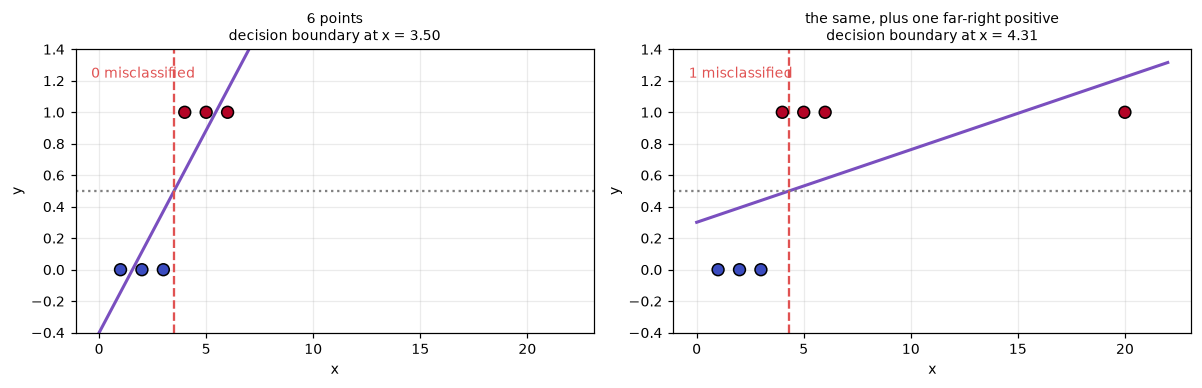

Adding a correctly-labelled, unambiguous point BROKE the classifier.
A model whose output is a straight line cannot be a probability.


In [14]:
X_cls = np.array([1., 2., 3., 4., 5., 6.])
y_cls = np.array([0., 0., 0., 1., 1., 1.])

# now add one extra positive example, far to the right - obviously class 1
X_out = np.append(X_cls, 20.0)
y_out = np.append(y_cls, 1.0)

grid = np.linspace(0, 22, 300)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, (Xd, yd, t) in zip(axes, [(X_cls, y_cls, "6 points"),
                                  (X_out, y_out, "the same, plus one far-right positive")]):
    w = fit_normal_equation(Xd, yd)
    pred = add_bias(grid) @ w
    boundary = (0.5 - w[0]) / w[1]
    ax.scatter(Xd, yd, c=yd, cmap="coolwarm", s=60, edgecolor="k", zorder=5)
    ax.plot(grid, pred, color=PURPLE, lw=2)
    ax.axhline(0.5, ls=":", color="gray"); ax.axvline(boundary, ls="--", color=RED)
    ax.set_ylim(-0.4, 1.4); ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title(f"{t}\ndecision boundary at x = {boundary:.2f}", fontsize=9)
    wrong = ((add_bias(Xd) @ w >= 0.5).astype(float) != yd).sum()
    ax.text(0.03, 0.9, f"{int(wrong)} misclassified", transform=ax.transAxes, fontsize=9, color=RED)
plt.tight_layout(); plt.show()

print("Adding a correctly-labelled, unambiguous point BROKE the classifier.")
print("A model whose output is a straight line cannot be a probability.")

## 3.2 The sigmoid, odds, and log-odds

We keep the linear part — it is interpretable and efficient — and squash its output into $(0,1)$ with the **sigmoid** (logistic) function:

$$z = \mathbf{w}^\top\mathbf{x} + b, \qquad \hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

Where does that particular function come from? Not from nowhere. Start from **odds**:

$$\text{odds} = \frac{p}{1-p} \in (0, \infty)$$

Take the log to spread it over the whole real line:

$$\text{logit}(p) = \log\frac{p}{1-p} \in (-\infty, \infty)$$

Now model *that* as a linear function of the features — which is legitimate, because it is unbounded like a linear function is:

$$\log\frac{p}{1-p} = \mathbf{w}^\top\mathbf{x} + b$$

Solve for $p$ and you get the sigmoid. So logistic regression is exactly **linear regression on the log-odds**, and the sigmoid is just the algebra of inverting the logit.

This gives the coefficients a precise meaning:

> $w_j$ is the change in the **log-odds** per unit of $x_j$. Equivalently, $e^{w_j}$ is the factor by which the **odds** are multiplied.

So a coefficient of $0.7$ means $e^{0.7} \approx 2$: one extra unit of that feature **doubles the odds**. That interpretation is why logistic regression remains the standard in medicine, credit scoring and epidemiology, where "why" matters as much as "what".

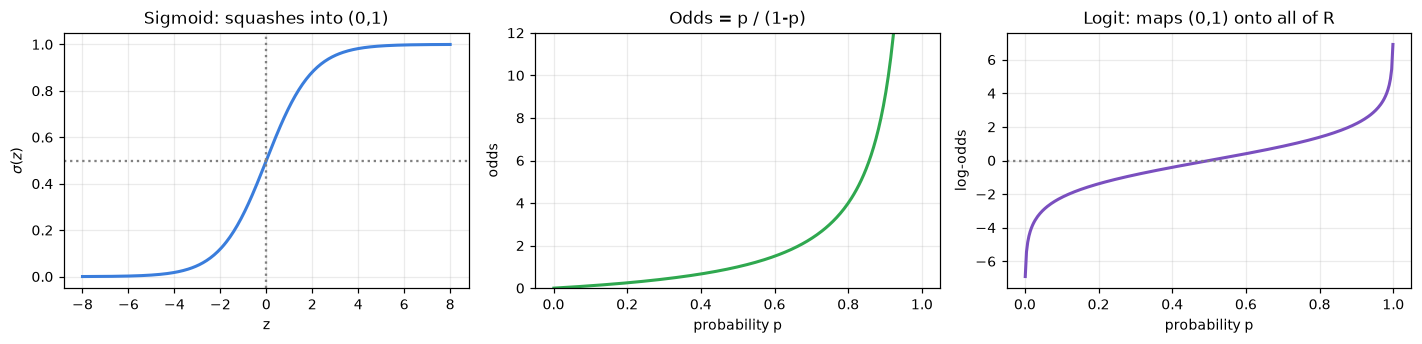

The link between the three:
   p = 0.10   odds =   0.11   log-odds = -2.20
   p = 0.25   odds =   0.33   log-odds = -1.10
   p = 0.50   odds =   1.00   log-odds = +0.00
   p = 0.75   odds =   3.00   log-odds = +1.10
   p = 0.90   odds =   9.00   log-odds = +2.20


In [15]:
def sigmoid(z):
    """Numerically stable sigmoid: avoids exp() overflow for large |z|."""
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1 / (1 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1 + ez)
    return out

z = np.linspace(-8, 8, 300)
p = np.linspace(0.001, 0.999, 300)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
axes[0].plot(z, sigmoid(z), color=BLUE, lw=2)
axes[0].axhline(0.5, ls=":", color="gray"); axes[0].axvline(0, ls=":", color="gray")
axes[0].set_xlabel("z"); axes[0].set_ylabel("$\\sigma(z)$"); axes[0].set_title("Sigmoid: squashes into (0,1)")

axes[1].plot(p, p / (1 - p), color=GREEN, lw=2)
axes[1].set_ylim(0, 12); axes[1].set_xlabel("probability p"); axes[1].set_ylabel("odds")
axes[1].set_title("Odds = p / (1-p)")

axes[2].plot(p, np.log(p / (1 - p)), color=PURPLE, lw=2)
axes[2].axhline(0, ls=":", color="gray")
axes[2].set_xlabel("probability p"); axes[2].set_ylabel("log-odds")
axes[2].set_title("Logit: maps (0,1) onto all of R")
plt.tight_layout(); plt.show()

print("The link between the three:")
for pv in [0.1, 0.25, 0.5, 0.75, 0.9]:
    print(f"   p = {pv:.2f}   odds = {pv/(1-pv):6.2f}   log-odds = {np.log(pv/(1-pv)):+.2f}")

## 3.3 The loss: why cross entropy and not MSE

Two independent arguments lead to the same loss.

**Argument 1: maximum likelihood.** If $\hat y_i$ is the model's probability that sample $i$ is class 1, the likelihood of the observed labels is

$$\mathcal{L}_{\text{lik}} = \prod_i \hat{y}_i^{\,y_i}(1-\hat{y}_i)^{1-y_i}$$

(each factor is $\hat y_i$ when $y_i = 1$ and $1-\hat y_i$ when $y_i = 0$). Products of many small numbers underflow, so take the log, and negate to make it a thing to minimize:

$$\mathcal{L} = -\frac{1}{m}\sum_i \Big[y_i\log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i)\Big]$$

That is **binary cross entropy**. It is not a heuristic — it is the negative log-likelihood.

**Argument 2: convexity.** Cross entropy composed with the sigmoid is **convex** in $\mathbf w$: one global minimum, gradient descent always finds it. MSE composed with the sigmoid is **not** convex — it has flat regions and local minima, so training can stall.

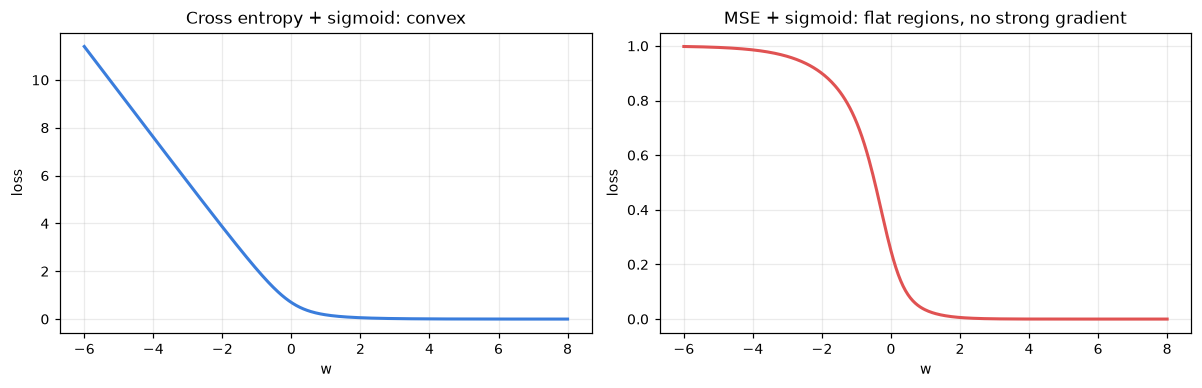

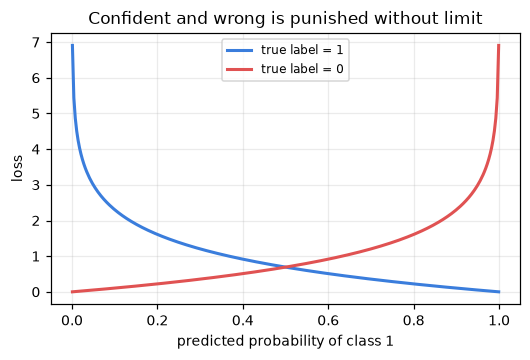

In [16]:
def bce_loss(y, y_hat, eps=1e-12):
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return float(-np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat)))


# the loss landscape along one weight, for both losses
Xs = np.array([[-2.], [-1.], [1.], [2.5], [3.]])
ys = np.array([0., 0., 1., 1., 1.])
ws = np.linspace(-6, 8, 400)

bce_curve = [bce_loss(ys, sigmoid(Xs[:, 0] * w)) for w in ws]
mse_curve = [np.mean((sigmoid(Xs[:, 0] * w) - ys) ** 2) for w in ws]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(ws, bce_curve, color=BLUE, lw=2)
axes[0].set_title("Cross entropy + sigmoid: convex"); axes[0].set_xlabel("w")
axes[1].plot(ws, mse_curve, color=RED, lw=2)
axes[1].set_title("MSE + sigmoid: flat regions, no strong gradient"); axes[1].set_xlabel("w")
for a in axes: a.set_ylabel("loss")
plt.tight_layout(); plt.show()

pv = np.linspace(0.001, 0.999, 300)
fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(pv, -np.log(pv), color=BLUE, lw=2, label="true label = 1")
ax.plot(pv, -np.log(1 - pv), color=RED, lw=2, label="true label = 0")
ax.set_xlabel("predicted probability of class 1"); ax.set_ylabel("loss")
ax.set_title("Confident and wrong is punished without limit"); ax.legend(fontsize=8)
plt.show()

## 3.4 The gradient, and the from-scratch implementation

Differentiating cross entropy through the sigmoid produces a remarkable simplification. Using $\sigma'(z) = \sigma(z)(1-\sigma(z))$, the two terms cancel and everything collapses to:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \frac{1}{m}X^\top(\hat{\mathbf{y}} - \mathbf{y})$$

Compare with linear regression: $\frac{2}{m}X^\top(\hat{\mathbf{y}} - \mathbf{y})$. **Identical up to a constant.** The prediction function changed; the update rule did not.

That is not a coincidence — it holds for the whole exponential family, and it is why the same backpropagation code in a neural network handles sigmoid+BCE, softmax+cross-entropy and linear+MSE without special cases.

In [17]:
class LogisticRegressionScratch:
    """Logistic regression with mini-batch gradient descent and optional L2."""

    def __init__(self, lr=0.1, epochs=500, batch_size=None, l2=0.0, seed=0):
        self.lr, self.epochs, self.batch_size, self.l2, self.seed = lr, epochs, batch_size, l2, seed

    def fit(self, X, y, verbose=0):
        Xb = add_bias(X)
        m, n = Xb.shape
        self.w = np.zeros(n)
        bs = self.batch_size or m
        rng = np.random.default_rng(self.seed)
        self.history = []

        for ep in range(self.epochs):
            idx = rng.permutation(m)
            for s in range(0, m, bs):
                b = idx[s:s + bs]
                y_hat = sigmoid(Xb[b] @ self.w)
                grad = Xb[b].T @ (y_hat - y[b]) / len(b)
                grad[1:] += self.l2 * self.w[1:]          # never regularize the intercept
                self.w -= self.lr * grad
            self.history.append(bce_loss(y, sigmoid(Xb @ self.w)))
            if verbose and ep % max(1, self.epochs // verbose) == 0:
                print(f"  epoch {ep:4d}  loss {self.history[-1]:.4f}")
        return self

    def predict_proba(self, X):
        return sigmoid(add_bias(X) @ self.w)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def score(self, X, y, threshold=0.5):
        return float(np.mean(self.predict(X, threshold) == y))


# a two-feature example we can draw
rng = np.random.default_rng(3)
n = 300
X_a = rng.normal([-1.2, -0.6], 1.0, size=(n // 2, 2))
X_b = rng.normal([1.4, 1.0], 1.0, size=(n // 2, 2))
X2 = np.vstack([X_a, X_b])
y2 = np.r_[np.zeros(n // 2), np.ones(n // 2)]

clf = LogisticRegressionScratch(lr=0.2, epochs=800).fit(X2, y2, verbose=4)
print(f"\nweights: intercept {clf.w[0]:+.3f}, w1 {clf.w[1]:+.3f}, w2 {clf.w[2]:+.3f}")
print(f"accuracy: {clf.score(X2, y2)*100:.1f}%")
print(f"\nOdds interpretation: one unit of x1 multiplies the odds by "
      f"exp({clf.w[1]:.2f}) = {np.exp(clf.w[1]):.2f}")

  epoch    0  loss 0.5857
  epoch  200  loss 0.1718
  epoch  400  loss 0.1689
  epoch  600  loss 0.1684

weights: intercept -0.771, w1 +2.552, w2 +1.433
accuracy: 94.0%

Odds interpretation: one unit of x1 multiplies the odds by exp(2.55) = 12.83


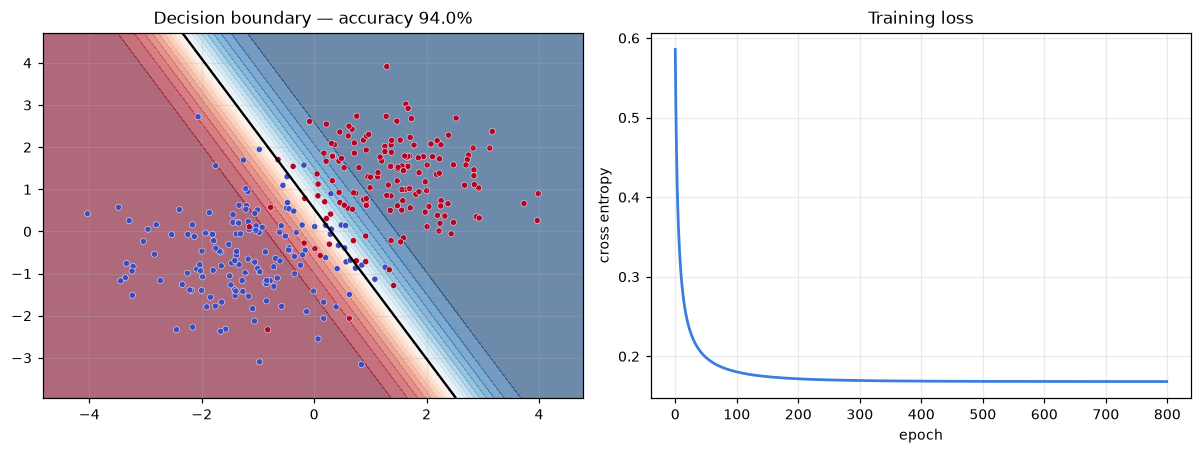

The boundary is the line where w0 + w1*x1 + w2*x2 = 0, i.e. probability = 0.5.
The colour gradient is the model's confidence: it is a probability model,
not just a separator. That is what makes threshold tuning possible (Part 4).


In [18]:
def plot_decision_boundary(predict_proba, X, y, ax=None, title="", pad=0.8, res=250):
    if ax is None:
        _, ax = plt.subplots(figsize=(4.8, 4.4))
    x0, x1 = X[:, 0].min() - pad, X[:, 0].max() + pad
    y0, y1 = X[:, 1].min() - pad, X[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x0, x1, res), np.linspace(y0, y1, res))
    zz = predict_proba(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=np.linspace(0, 1, 21), cmap="RdBu", alpha=0.6)
    ax.contour(xx, yy, zz, levels=[0.5], colors="k", linewidths=1.6)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=16, edgecolor="w", linewidth=0.3)
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.set_title(title)
    return ax


fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
plot_decision_boundary(clf.predict_proba, X2, y2, ax=axes[0],
                       title=f"Decision boundary — accuracy {clf.score(X2, y2)*100:.1f}%")
axes[1].plot(clf.history, color=BLUE, lw=1.8)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("cross entropy"); axes[1].set_title("Training loss")
plt.tight_layout(); plt.show()

print("The boundary is the line where w0 + w1*x1 + w2*x2 = 0, i.e. probability = 0.5.")
print("The colour gradient is the model's confidence: it is a probability model,")
print("not just a separator. That is what makes threshold tuning possible (Part 4).")

## 3.5 More than two classes

Two standard extensions:

**One-vs-Rest (OvR).** Train $C$ separate binary classifiers, "class $c$ vs everything else", and take the highest score. Simple, works with any binary classifier, but the probabilities are not calibrated against each other.

**Multinomial (softmax) regression.** One weight vector per class, turned into a proper distribution:

$$\hat{y}_c = \frac{e^{\mathbf{w}_c^\top \mathbf{x}}}{\sum_{k} e^{\mathbf{w}_k^\top \mathbf{x}}}$$

with categorical cross entropy as the loss. This is the principled version and the default in scikit-learn. Note that softmax with $C=2$ reduces exactly to the sigmoid.

training accuracy on iris: 95.3%


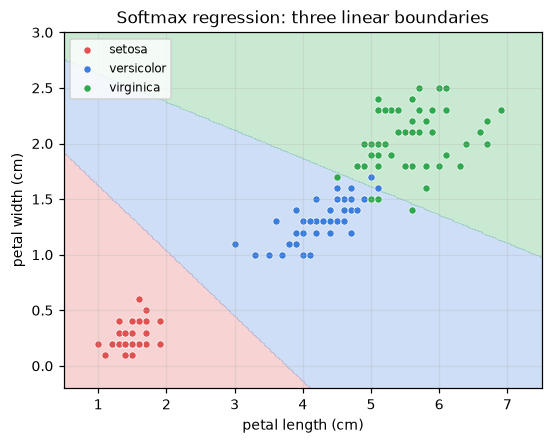

In [19]:
def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)          # stability
    e = np.exp(Z)
    return e / e.sum(axis=1, keepdims=True)


class SoftmaxRegression:
    def __init__(self, n_classes, lr=0.5, epochs=800, l2=0.0):
        self.C, self.lr, self.epochs, self.l2 = n_classes, lr, epochs, l2

    def fit(self, X, y):
        Xb = add_bias(X)
        m, n = Xb.shape
        self.W = np.zeros((n, self.C))
        Y = np.zeros((m, self.C)); Y[np.arange(m), y.astype(int)] = 1
        for _ in range(self.epochs):
            P = softmax(Xb @ self.W)
            grad = Xb.T @ (P - Y) / m              # the SAME formula again
            grad[1:] += self.l2 * self.W[1:]
            self.W -= self.lr * grad
        return self

    def predict_proba(self, X):
        return softmax(add_bias(X) @ self.W)

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)


from sklearn.datasets import load_iris
iris = load_iris()
Xi, yi = iris.data[:, [2, 3]], iris.target          # petal length and width

sm = SoftmaxRegression(3, lr=0.5, epochs=3000).fit(Xi, yi)
print(f"training accuracy on iris: {np.mean(sm.predict(Xi) == yi)*100:.1f}%")

xx, yy = np.meshgrid(np.linspace(0.5, 7.5, 300), np.linspace(-0.2, 3.0, 300))
zz = sm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.figure(figsize=(5.6, 4.2))
plt.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5, 2.5], colors=[RED, BLUE, GREEN], alpha=0.25)
for c, col in zip(range(3), [RED, BLUE, GREEN]):
    plt.scatter(Xi[yi == c, 0], Xi[yi == c, 1], color=col, s=22,
                edgecolor="w", linewidth=0.4, label=iris.target_names[c])
plt.xlabel("petal length (cm)"); plt.ylabel("petal width (cm)")
plt.title("Softmax regression: three linear boundaries"); plt.legend(fontsize=8)
plt.show()

---

# Part 4 — Evaluating a classifier properly

## 4.1 The confusion matrix and what comes out of it

Every prediction falls into one of four boxes:

|  | predicted 0 | predicted 1 |
|---|---|---|
| **actual 0** | TN | FP (false alarm) |
| **actual 1** | FN (miss) | TP |

From these four numbers:

$$
\text{accuracy} = \frac{TP+TN}{\text{all}}, \qquad
\text{precision} = \frac{TP}{TP+FP}, \qquad
\text{recall} = \frac{TP}{TP+FN}, \qquad
F_1 = \frac{2PR}{P+R}
$$

* **Precision** — when it says "yes", how often is it right? Matters when false alarms are expensive.
* **Recall** (sensitivity) — of all the real positives, how many did we catch? Matters when misses are expensive.
* **Specificity** — the same as recall, for the negative class.

**Accuracy is dangerous on imbalanced data.** If 1% of transactions are fraud, "never fraud" scores 99% and is worthless. This comes back as Challenge 5.

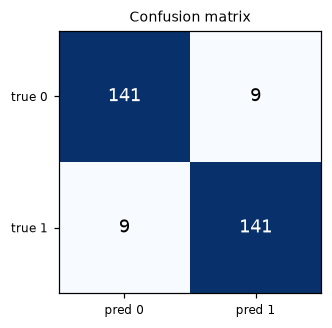

      accuracy: 0.940
     precision: 0.940
        recall: 0.940
   specificity: 0.940
            f1: 0.940


In [20]:
def confusion_matrix(y, y_pred, n_classes=2):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(np.asarray(y).astype(int), np.asarray(y_pred).astype(int)):
        cm[t, p] += 1
    return cm


def classification_metrics(y, y_pred):
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    precision = tp / max(1, tp + fp)
    recall = tp / max(1, tp + fn)
    return {
        "accuracy": (tp + tn) / len(y),
        "precision": precision,
        "recall": recall,
        "specificity": tn / max(1, tn + fp),
        "f1": 2 * precision * recall / max(1e-12, precision + recall),
    }


def plot_confusion(cm, labels=("0", "1"), ax=None, title="Confusion matrix"):
    if ax is None:
        _, ax = plt.subplots(figsize=(3.4, 3.1))
    ax.imshow(cm, cmap="Blues")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=12,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks(range(len(labels)), [f"pred {l}" for l in labels], fontsize=8)
    ax.set_yticks(range(len(labels)), [f"true {l}" for l in labels], fontsize=8)
    ax.set_title(title, fontsize=9); ax.grid(False)
    return ax


pred2 = clf.predict(X2)
plot_confusion(confusion_matrix(y2, pred2)); plt.show()
for k, v in classification_metrics(y2, pred2).items():
    print(f"  {k:>12}: {v:.3f}")

## 4.2 The threshold is a free parameter

Logistic regression outputs a **probability**. Turning it into a decision requires a threshold, and 0.5 has no special status — it is just the default. Moving the threshold trades precision against recall, and the right value depends on the relative cost of a miss versus a false alarm.

* Cancer screening: a miss is catastrophic, a false alarm means another test → **low threshold, high recall**.
* Spam filtering: a false alarm loses a real email → **high threshold, high precision**.

Two curves summarize every threshold at once:

**ROC curve** — true positive rate against false positive rate. The area under it (**AUC**) is the probability that the model scores a random positive above a random negative. 0.5 = random, 1.0 = perfect.

**Precision-Recall curve** — better than ROC when the positive class is rare, because ROC's false-positive rate has a huge denominator and hides the problem.

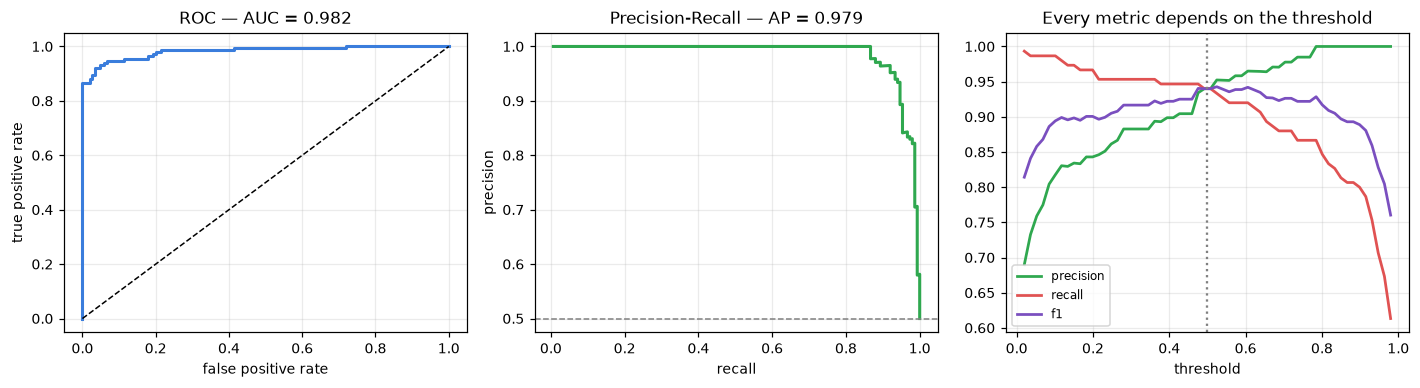

In [21]:
def roc_curve(y, scores):
    order = np.argsort(-scores)
    y = np.asarray(y)[order]
    tps = np.cumsum(y == 1)
    fps = np.cumsum(y == 0)
    tpr = np.r_[0, tps / max(1, (y == 1).sum())]
    fpr = np.r_[0, fps / max(1, (y == 0).sum())]
    return fpr, tpr


def auc(x, y):
    return float(np.trapezoid(y, x)) if hasattr(np, "trapezoid") else float(np.trapz(y, x))


def pr_curve(y, scores):
    order = np.argsort(-scores)
    y = np.asarray(y)[order]
    tps = np.cumsum(y == 1)
    precision = tps / np.arange(1, len(y) + 1)
    recall = tps / max(1, (y == 1).sum())
    return recall, precision


scores = clf.predict_proba(X2)
fpr, tpr = roc_curve(y2, scores)
rec, prec = pr_curve(y2, scores)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].plot(fpr, tpr, color=BLUE, lw=2)
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
axes[0].set_title(f"ROC — AUC = {auc(fpr, tpr):.3f}")

axes[1].plot(rec, prec, color=GREEN, lw=2)
axes[1].axhline(y2.mean(), ls="--", color="gray", lw=1)
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title(f"Precision-Recall — AP = {auc(rec, prec):.3f}")

ths = np.linspace(0.02, 0.98, 60)
for key, color in [("precision", GREEN), ("recall", RED), ("f1", PURPLE)]:
    axes[2].plot(ths, [classification_metrics(y2, (scores >= t).astype(int))[key] for t in ths],
                 color=color, lw=1.8, label=key)
axes[2].axvline(0.5, ls=":", color="gray")
axes[2].set_xlabel("threshold"); axes[2].legend(fontsize=8)
axes[2].set_title("Every metric depends on the threshold")
plt.tight_layout(); plt.show()

## 4.3 Calibration

A probability of 0.8 should mean "right about 80% of the time". A model can rank perfectly (AUC 1.0) while being badly calibrated. Logistic regression trained with cross entropy is usually **well calibrated out of the box** — a real advantage over SVMs, naive Bayes and boosted trees, which often need a separate calibration step.

The check is a **reliability diagram**: bin the predictions and plot the observed frequency against the predicted probability.

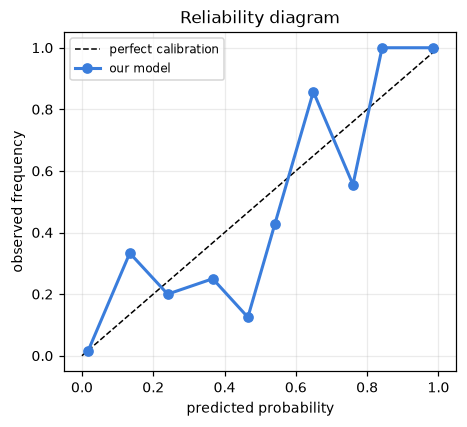

Points on the diagonal mean the probabilities can be trusted as probabilities,
not merely as scores. That matters whenever you feed them into a cost calculation.


In [22]:
def calibration_curve(y, prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.digitize(prob, bins) - 1
    xs, ys, counts = [], [], []
    for b in range(n_bins):
        m = idx == b
        if m.sum() > 0:
            xs.append(prob[m].mean()); ys.append(y[m].mean()); counts.append(m.sum())
    return np.array(xs), np.array(ys), np.array(counts)


xs, ys_, cnt = calibration_curve(y2, scores)
plt.figure(figsize=(4.6, 4))
plt.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
plt.plot(xs, ys_, "o-", color=BLUE, lw=2, label="our model")
plt.xlabel("predicted probability"); plt.ylabel("observed frequency")
plt.title("Reliability diagram"); plt.legend(fontsize=8)
plt.show()

print("Points on the diagonal mean the probabilities can be trusted as probabilities,")
print("not merely as scores. That matters whenever you feed them into a cost calculation.")

Solutions

1. Platt scaling
2. Isotonic regression

---

# Part 5 — Regularization

## 5.1 The problem

Add enough features — polynomials, interactions, dummies — and a linear model becomes flexible enough to fit noise. The symptom is always the same: **large coefficients that cancel each other out**, producing a wildly oscillating function that passes through every training point.

Regularization adds a penalty on coefficient size, so the model must *earn* every large weight.

| Method | Penalty added to the loss | Effect |
|---|---|---|
| **Ridge (L2)** | $\lambda \sum w_j^2$ | shrinks all weights smoothly towards zero; keeps every feature |
| **Lasso (L1)** | $\lambda \sum \lvert w_j \rvert$ | drives some weights **exactly to zero** — automatic feature selection |
| **Elastic Net** | $\lambda(\rho\sum\lvert w_j\rvert + \frac{1-\rho}{2}\sum w_j^2)$ | both; handles correlated feature groups better than Lasso |

Ridge has a closed form — and notice that adding $\lambda I$ makes the matrix invertible, which is exactly the multicollinearity cure from Part 2.3:

$$\mathbf{w} = (X^\top X + \lambda I)^{-1}X^\top\mathbf{y}$$

Lasso does not, because $|w|$ is not differentiable at zero; it is solved by coordinate descent or proximal gradient methods.

**Two rules that are easy to get wrong:**

1. **Never penalize the intercept.** It is not a feature, and shrinking it just biases predictions.
2. **Always scale your features first.** The penalty treats all coefficients equally, so a feature measured in millimetres gets penalized far more than the same feature in metres.

### Why L1 gives exact zeros

The geometric explanation: the constraint region for L1 is a diamond (corners on the axes) and for L2 a circle. The loss contours expand until they touch the region — and a diamond is most likely to be touched **at a corner**, where one coordinate is exactly zero. A circle has no corners, so nothing lands exactly on an axis.

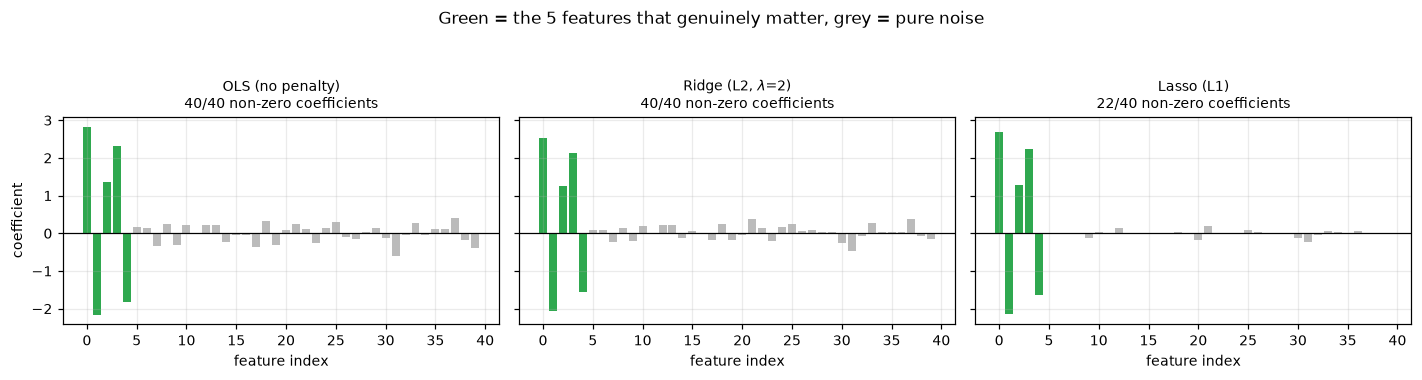

model                   train R2   true-coef error
----------------------------------------------------
OLS                        0.987              7.65
Ridge                      0.983              6.81
Lasso                      0.976              2.47

OLS fits the training data best and recovers the truth worst - the definition
of overfitting. Lasso zeroes out most of the noise features automatically.


In [23]:
def fit_ridge(X, y, lam=1.0):
    """Closed-form ridge. The intercept is not penalized."""
    Xb = add_bias(X)
    n = Xb.shape[1]
    I = np.eye(n); I[0, 0] = 0.0                 # <- do not penalize the intercept
    return np.linalg.solve(Xb.T @ Xb + lam * I, Xb.T @ y)


def fit_lasso(X, y, lam=1.0, iters=1000, tol=1e-8):
    """Lasso via coordinate descent. Assumes X is already standardized."""
    Xb = add_bias(X)
    m, n = Xb.shape
    w = np.zeros(n)
    norms = (Xb ** 2).sum(axis=0)
    for _ in range(iters):
        w_old = w.copy()
        for j in range(n):
            r = y - Xb @ w + Xb[:, j] * w[j]     # residual excluding feature j
            rho = Xb[:, j] @ r
            if j == 0:
                w[j] = rho / norms[j]            # intercept: no penalty
            else:                                # soft-thresholding operator
                w[j] = np.sign(rho) * max(abs(rho) - lam * m / 2, 0) / norms[j]
        if np.max(np.abs(w - w_old)) < tol:
            break
    return w


# 40 features, only 5 of which matter
rng = np.random.default_rng(5)
m, n_feat, n_true = 60, 40, 5
Xr = rng.normal(size=(m, n_feat))
true_w = np.zeros(n_feat); true_w[:n_true] = [3, -2, 1.5, 2.5, -1.8]
yr = Xr @ true_w + rng.normal(0, 1.0, m)

w_ols = fit_normal_equation(Xr, yr)
w_ridge = fit_ridge(Xr, yr, lam=2.0)
w_lasso = fit_lasso(Xr, yr, lam=0.15)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
for ax, w, t in [(axes[0], w_ols, "OLS (no penalty)"),
                 (axes[1], w_ridge, "Ridge (L2, $\\lambda$=2)"),
                 (axes[2], w_lasso, "Lasso (L1)")]:
    ax.bar(range(n_feat), w[1:], color=[GREEN if i < n_true else "#bbb" for i in range(n_feat)])
    ax.axhline(0, color="k", lw=0.8)
    nz = int((np.abs(w[1:]) > 1e-6).sum())
    ax.set_title(f"{t}\n{nz}/{n_feat} non-zero coefficients", fontsize=9)
    ax.set_xlabel("feature index")
axes[0].set_ylabel("coefficient")
plt.suptitle("Green = the 5 features that genuinely matter, grey = pure noise", y=1.06)
plt.tight_layout(); plt.show()

print(f"{'model':<22} {'train R2':>9} {'true-coef error':>17}")
print("-" * 52)
for w, t in [(w_ols, "OLS"), (w_ridge, "Ridge"), (w_lasso, "Lasso")]:
    r2 = regression_metrics(yr, add_bias(Xr) @ w)["R2"]
    err = np.abs(w[1:] - true_w).sum()
    print(f"{t:<22} {r2:>9.3f} {err:>17.2f}")
print("\nOLS fits the training data best and recovers the truth worst - the definition")
print("of overfitting. Lasso zeroes out most of the noise features automatically.")

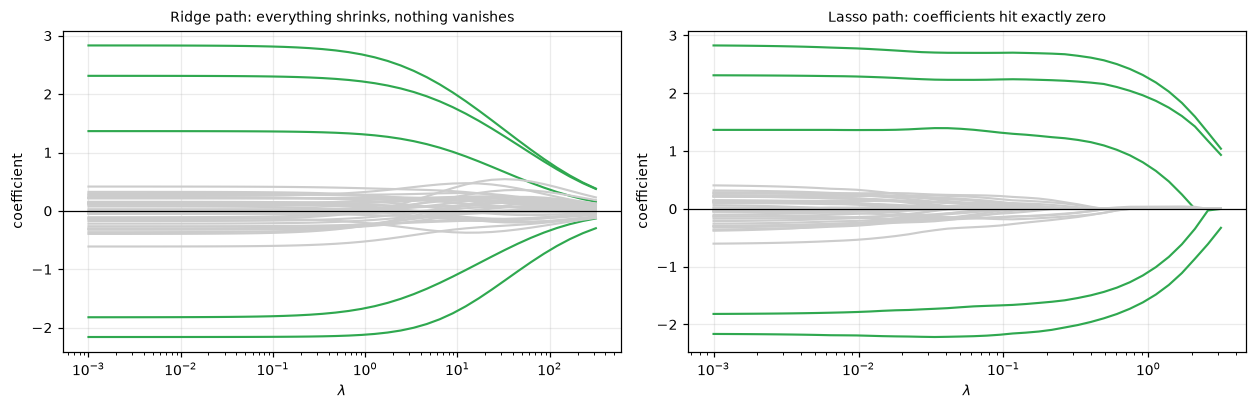

In [24]:
# the regularization path: how coefficients evolve as lambda grows
lams = np.logspace(-3, 2.5, 40)
paths_ridge = np.array([fit_ridge(Xr, yr, lam=l)[1:] for l in lams])
paths_lasso = np.array([fit_lasso(Xr, yr, lam=l, iters=200)[1:] for l in np.logspace(-3, 0.5, 40)])

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
for j in range(n_feat):
    c = GREEN if j < n_true else "#ccc"
    axes[0].plot(lams, paths_ridge[:, j], color=c, lw=1.4)
    axes[1].plot(np.logspace(-3, 0.5, 40), paths_lasso[:, j], color=c, lw=1.4)
for ax, t in [(axes[0], "Ridge path: everything shrinks, nothing vanishes"),
              (axes[1], "Lasso path: coefficients hit exactly zero")]:
    ax.set_xscale("log"); ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel("$\\lambda$"); ax.set_ylabel("coefficient"); ax.set_title(t, fontsize=9)
plt.tight_layout(); plt.show()

## 5.2 Choosing $\lambda$ with cross-validation

$\lambda$ is a hyperparameter — it cannot be learned from the training loss, because the training loss always prefers $\lambda = 0$. It has to be chosen on data the fit did not see.

**k-fold cross-validation** splits the training data into $k$ parts, trains on $k-1$ and validates on the remaining one, $k$ times, then averages. It uses all the data for both roles and gives a much less noisy estimate than a single split.

Variants worth knowing: **StratifiedKFold** preserves class proportions (always use it for classification), **GroupKFold** keeps related samples together, and **TimeSeriesSplit** never trains on the future.

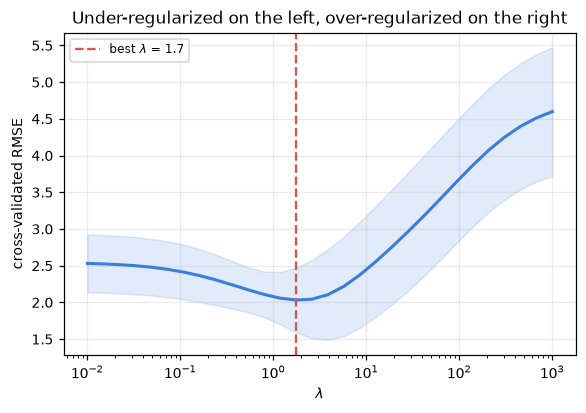

CV RMSE, no regularization (lambda -> 0): 2.547
CV RMSE, best lambda = 1.7          : 2.033
improvement: 20%


In [25]:
def k_fold_indices(m, k=5, seed=0):
    idx = np.random.default_rng(seed).permutation(m)
    return [(np.setdiff1d(idx, f), f) for f in np.array_split(idx, k)]


def cv_score_ridge(X, y, lam, k=5):
    scores = []
    for tr, va in k_fold_indices(len(y), k):
        w = fit_ridge(X[tr], y[tr], lam=lam)
        scores.append(regression_metrics(y[va], add_bias(X[va]) @ w)["RMSE"])
    return float(np.mean(scores)), float(np.std(scores))


lams = np.logspace(-2, 3, 30)
means, stds = zip(*[cv_score_ridge(Xr, yr, l) for l in lams])
means, stds = np.array(means), np.array(stds)
best = lams[means.argmin()]

plt.figure(figsize=(6, 3.8))
plt.plot(lams, means, color=BLUE, lw=2)
plt.fill_between(lams, means - stds, means + stds, color=BLUE, alpha=0.15)
plt.axvline(best, ls="--", color=RED, label=f"best $\\lambda$ = {best:.1f}")
plt.xscale("log"); plt.xlabel("$\\lambda$"); plt.ylabel("cross-validated RMSE")
plt.title("Under-regularized on the left, over-regularized on the right"); plt.legend(fontsize=8)
plt.show()

print(f"CV RMSE, no regularization (lambda -> 0): {cv_score_ridge(Xr, yr, 1e-8)[0]:.3f}")
print(f"CV RMSE, best lambda = {best:.1f}          : {means.min():.3f}")
print(f"improvement: {(1 - means.min()/cv_score_ridge(Xr, yr, 1e-8)[0])*100:.0f}%")

---

# Part 6 — The same models with scikit-learn

Now that nothing is mysterious, use the library. It is faster, better tested, handles edge cases, and — most importantly — its `Pipeline` makes it hard to leak data.

## 6.1 The estimator API

Every model in scikit-learn has the same three methods:

```python
model.fit(X, y)          # learn the parameters
model.predict(X)         # predict
model.score(X, y)        # R^2 for regressors, accuracy for classifiers
```

Classifiers add `predict_proba`. Transformers have `fit_transform`. That uniformity is why you can swap a linear model for a gradient boosting model by changing one line.

In [26]:
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                  LogisticRegression, SGDRegressor)
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                             classification_report, roc_auc_score, confusion_matrix as sk_cm)

# --- does sklearn agree with our from-scratch code?
lr = LinearRegression().fit(Xr, yr)
print("linear regression")
print(f"  ours    : intercept {w_ols[0]:+.4f}   first 3 coefs {np.round(w_ols[1:4], 4)}")
print(f"  sklearn : intercept {lr.intercept_:+.4f}   first 3 coefs {np.round(lr.coef_[:3], 4)}")

# sklearn's Ridge uses alpha where we used lambda - the same thing
rg = Ridge(alpha=10.0).fit(Xr, yr)
print("\nridge (alpha = 10)")
print(f"  ours    : {np.round(w_ridge[1:4], 4)}")
print(f"  sklearn : {np.round(rg.coef_[:3], 4)}")

lo = LogisticRegression(penalty=None, max_iter=2000).fit(X2, y2)
print("\nlogistic regression")
print(f"  ours    : {np.round(clf.w, 3)}")
print(f"  sklearn : {np.round(np.r_[lo.intercept_, lo.coef_[0]], 3)}")
print("\nSmall differences: sklearn uses a second-order solver (lbfgs) rather than")
print("plain gradient descent, so it lands closer to the exact optimum.")

linear regression
  ours    : intercept +0.3404   first 3 coefs [ 2.834  -2.1598  1.3665]
  sklearn : intercept +0.3404   first 3 coefs [ 2.834  -2.1598  1.3665]

ridge (alpha = 10)
  ours    : [ 2.5385 -2.0703  1.2563]
  sklearn : [ 1.9755 -1.7125  0.9846]

logistic regression
  ours    : [-0.771  2.552  1.433]
  sklearn : [-0.789  2.593  1.452]

Small differences: sklearn uses a second-order solver (lbfgs) rather than
plain gradient descent, so it lands closer to the exact optimum.


/Users/amirhossein/Library/Python/3.14/lib/python/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


> **A note on scikit-learn's Lasso**: its `alpha` is scaled differently from the $\lambda$ in our implementation (sklearn divides the squared-error term by $2m$). Do not expect the same number to give the same amount of shrinkage — always select it by cross-validation.

## 6.2 Pipelines: the single most important habit

Consider this innocent-looking code:

```python
X_scaled = StandardScaler().fit_transform(X)          # <-- BUG
X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y)
```

The scaler computed its mean and standard deviation from **the whole dataset, including the test set**. Information has leaked from the test data into the training process, and your reported score is optimistic. The same bug appears with imputation, target encoding, and feature selection.

A `Pipeline` makes this structurally impossible: every step's `fit` sees only the training fold, and cross-validation re-fits the entire chain inside each fold.

In [27]:
from sklearn.datasets import load_diabetes
dia = load_diabetes()
Xd, yd = dia.data, dia.target
print("diabetes dataset:", Xd.shape, "| target = disease progression after one year")
print("features:", dia.feature_names)

Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, test_size=0.25, random_state=0)

pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", Ridge(alpha=1.0)),
])
pipe.fit(Xd_tr, yd_tr)

print(f"\ntrain R2: {pipe.score(Xd_tr, yd_tr):.3f}")
print(f"test  R2: {pipe.score(Xd_te, yd_te):.3f}")
print(f"test RMSE: {np.sqrt(mean_squared_error(yd_te, pipe.predict(Xd_te))):.1f}")

cv = cross_val_score(pipe, Xd_tr, yd_tr, cv=KFold(5, shuffle=True, random_state=0), scoring="r2")
print(f"\n5-fold CV R2 on the training set: {cv.mean():.3f} +/- {cv.std():.3f}")
print("Inside cross_val_score the scaler is re-fitted on each fold. No leakage.")

diabetes dataset: (442, 10) | target = disease progression after one year
features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

train R2: 0.555
test  R2: 0.358
test RMSE: 56.5

5-fold CV R2 on the training set: 0.523 +/- 0.076
Inside cross_val_score the scaler is re-fitted on each fold. No leakage.


best alpha: 31.62
best CV R2: 0.5235
test   R2 : 0.3659


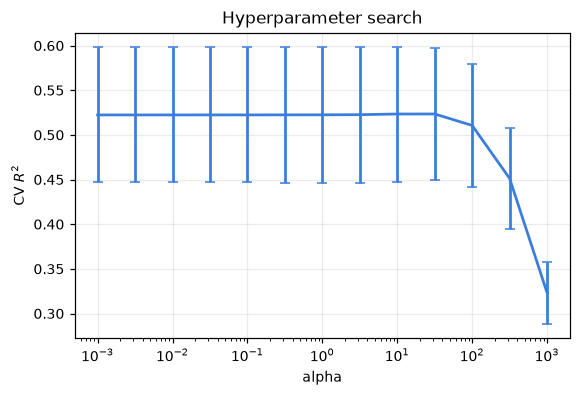

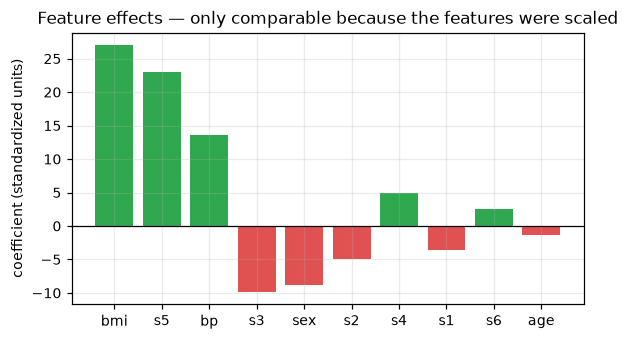

In [28]:
# GridSearchCV: search hyperparameters with cross-validation, correctly
param_grid = {
    "model__alpha": np.logspace(-3, 3, 13),
}
gs = GridSearchCV(pipe, param_grid, cv=KFold(5, shuffle=True, random_state=0),
                  scoring="r2", n_jobs=1)
gs.fit(Xd_tr, yd_tr)

print(f"best alpha: {gs.best_params_['model__alpha']:.4g}")
print(f"best CV R2: {gs.best_score_:.4f}")
print(f"test   R2 : {gs.score(Xd_te, yd_te):.4f}")

res = gs.cv_results_
plt.figure(figsize=(5.8, 3.6))
plt.errorbar(param_grid["model__alpha"], res["mean_test_score"],
             yerr=res["std_test_score"], color=BLUE, lw=1.8, capsize=3)
plt.xscale("log"); plt.xlabel("alpha"); plt.ylabel("CV $R^2$")
plt.title("Hyperparameter search")
plt.show()

# which features matter? (coefficients are comparable because we scaled)
coefs = gs.best_estimator_.named_steps["model"].coef_
order = np.argsort(-np.abs(coefs))
plt.figure(figsize=(6, 3.2))
plt.bar([dia.feature_names[i] for i in order], coefs[order],
        color=[GREEN if c > 0 else RED for c in coefs[order]])
plt.axhline(0, color="k", lw=0.8); plt.ylabel("coefficient (standardized units)")
plt.title("Feature effects — only comparable because the features were scaled")
plt.show()

## 6.3 Classification with scikit-learn

Two arguments to `LogisticRegression` you will use constantly:

* `C` — the **inverse** regularization strength. Small `C` means strong regularization. (Yes, it is the reciprocal of $\lambda$; blame the SVM literature.)
* `class_weight="balanced"` — automatically weights classes inversely to their frequency. Essential for imbalanced data (Challenge 5).

Also note that scikit-learn's `LogisticRegression` applies **L2 regularization by default**. If you want the raw maximum-likelihood fit, pass `penalty=None`.

breast cancer dataset: (569, 30) | classes: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}

accuracy: 0.9580
ROC AUC : 0.9952

              precision    recall  f1-score   support

   malignant       0.94      0.94      0.94        53
      benign       0.97      0.97      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143



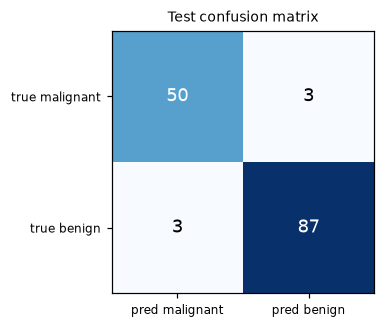

In [29]:
from sklearn.datasets import load_breast_cancer
bc = load_breast_cancer()
Xb_, yb_ = bc.data, bc.target
print("breast cancer dataset:", Xb_.shape, "| classes:", dict(zip(bc.target_names, np.bincount(yb_))))

Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb_, yb_, test_size=0.25,
                                              random_state=0, stratify=yb_)

clf_pipe = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=5000))
clf_pipe.fit(Xb_tr, yb_tr)

proba = clf_pipe.predict_proba(Xb_te)[:, 1]
pred = clf_pipe.predict(Xb_te)

print(f"\naccuracy: {accuracy_score(yb_te, pred):.4f}")
print(f"ROC AUC : {roc_auc_score(yb_te, proba):.4f}")
print("\n" + classification_report(yb_te, pred, target_names=bc.target_names))

plot_confusion(sk_cm(yb_te, pred), labels=bc.target_names, title="Test confusion matrix")
plt.show()

### Try it without scaling

Watch what happens when the features are left on their original scales. This dataset has features ranging from 0.05 to 4000, and the solver has to fight the geometry.

In [30]:
import warnings
from sklearn.exceptions import ConvergenceWarning

for name, model in [("no scaling ", LogisticRegression(C=1.0, max_iter=200)),
                    ("with scaler", make_pipeline(StandardScaler(),
                                                  LogisticRegression(C=1.0, max_iter=200)))]:
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", ConvergenceWarning)
        model.fit(Xb_tr, yb_tr)
        converged = not any(issubclass(w.category, ConvergenceWarning) for w in caught)
    acc = model.score(Xb_te, yb_te)
    print(f"{name}: test accuracy {acc:.4f}   converged in 200 iterations: {converged}")

print("\nSame model, same data, same iteration budget. Scaling is not optional.")

no scaling : test accuracy 0.9301   converged in 200 iterations: False
with scaler: test accuracy 0.9580   converged in 200 iterations: True

Same model, same data, same iteration budget. Scaling is not optional.


---

# Part 7 — Preprocessing

Linear models are simple, which means they are **unusually sensitive to how the data is prepared**. This is where most of the practical work lives.

## 7.1 Scaling

| Scaler | Formula | Use when |
|---|---|---|
| **StandardScaler** | $(x - \mu)/\sigma$ | the default; features roughly bell-shaped |
| **MinMaxScaler** | $(x - \min)/(\max - \min)$ | you need a bounded range; **very** outlier-sensitive |
| **RobustScaler** | $(x - \text{median})/\text{IQR}$ | there are outliers |
| **MaxAbsScaler** | $x/\max\lvert x\rvert$ | sparse data (preserves zeros) |
| **QuantileTransformer** | rank → uniform or normal | strongly non-Gaussian features |

Scaling matters for three separate reasons, and they are worth keeping distinct:

1. **Optimization** — gradient descent converges far faster on a round loss surface than on a ravine.
2. **Regularization** — the penalty is applied per coefficient, so unscaled features are penalized inconsistently.
3. **Interpretation** — after standardizing, coefficient magnitudes are directly comparable.

(Scaling does *not* change the predictions of unregularized OLS solved in closed form. It changes everything else.)

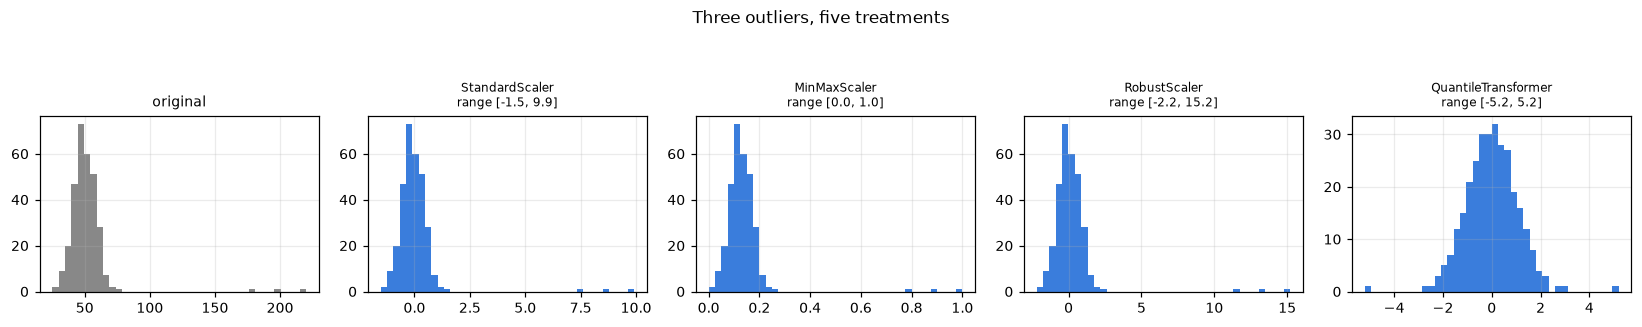

MinMax squeezes 99% of the data into a tiny sliver because of 3 points.
RobustScaler uses the median and IQR, so the outliers barely move it.


In [31]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler, QuantileTransformer

rng = np.random.default_rng(0)
data = np.r_[rng.normal(50, 8, 300), [180, 200, 220]]        # 3 outliers

scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler(),
    "QuantileTransformer": QuantileTransformer(n_quantiles=100, output_distribution="normal"),
}

fig, axes = plt.subplots(1, 5, figsize=(15, 2.7))
axes[0].hist(data, bins=40, color="#888"); axes[0].set_title("original", fontsize=9)
for ax, (name, sc) in zip(axes[1:], scalers.items()):
    out = sc.fit_transform(data.reshape(-1, 1)).ravel()
    ax.hist(out, bins=40, color=BLUE)
    ax.set_title(f"{name}\nrange [{out.min():.1f}, {out.max():.1f}]", fontsize=8)
plt.suptitle("Three outliers, five treatments", y=1.08)
plt.tight_layout(); plt.show()

print("MinMax squeezes 99% of the data into a tiny sliver because of 3 points.")
print("RobustScaler uses the median and IQR, so the outliers barely move it.")

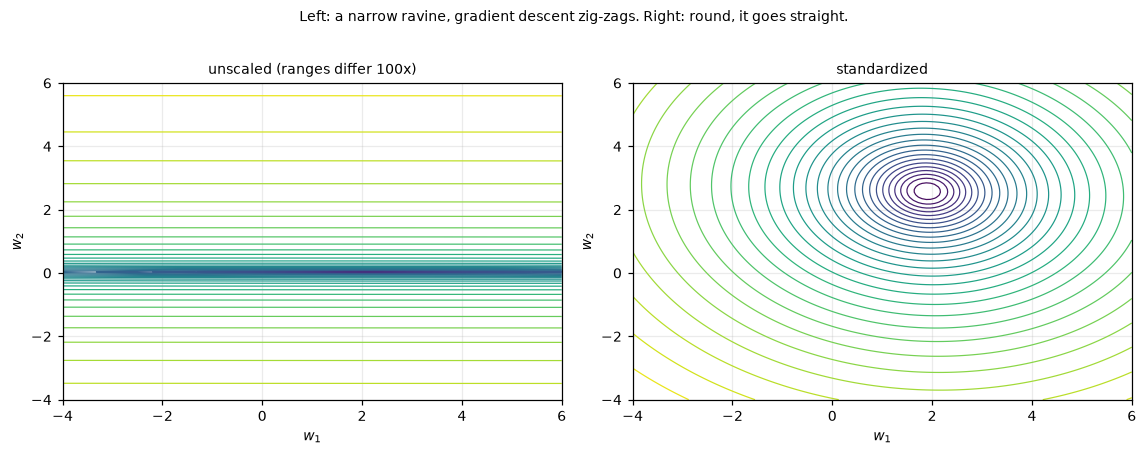

In [32]:
# why scaling changes the shape of the loss surface
rng = np.random.default_rng(1)
n = 200
x_small = rng.normal(0, 1, n)
x_large = rng.normal(0, 100, n)                 # same information, different units
y_sc = 2 * x_small + 0.03 * x_large + rng.normal(0, 0.5, n)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
for ax, X, t in [(axes[0], np.c_[x_small, x_large], "unscaled (ranges differ 100x)"),
                 (axes[1], StandardScaler().fit_transform(np.c_[x_small, x_large]), "standardized")]:
    w1 = np.linspace(-4, 6, 120); w2 = np.linspace(-4, 6, 120)
    W1, W2 = np.meshgrid(w1, w2)
    Z = np.array([[np.mean((X @ np.array([a, b]) - y_sc) ** 2) for a in w1] for b in w2])
    ax.contour(W1, W2, np.log10(Z + 1e-9), levels=30, cmap="viridis", linewidths=0.8)
    ax.set_xlabel("$w_1$"); ax.set_ylabel("$w_2$"); ax.set_title(t, fontsize=9)
plt.suptitle("Left: a narrow ravine, gradient descent zig-zags. Right: round, it goes straight.",
             y=1.02, fontsize=9)
plt.tight_layout(); plt.show()

## 7.2 Missing values

Linear models cannot consume `NaN`. Options, roughly in order of sophistication:

| Strategy | Notes |
|---|---|
| Drop rows | fine if very few; throws away data and can bias the sample |
| Drop columns | only if the column is mostly empty |
| **Mean / median imputation** | the default. Median is safer with skew |
| Most frequent | for categorical features |
| **Add a "was missing" indicator** | often the single highest-value trick — missingness is frequently informative |
| Iterative / KNN imputation | model each feature from the others; slower, sometimes much better |

The reason the indicator column helps so often: *why* a value is missing usually carries signal. A blank income field on a loan application is not random.

**Always impute inside a Pipeline**, so the statistics come from the training fold only.

In [33]:
from sklearn.impute import SimpleImputer

rng = np.random.default_rng(2)
n = 800
x1 = rng.normal(0, 1, n)
x2 = rng.normal(0, 1, n)
y_mi = 2 * x1 + x2 + rng.normal(0, 0.4, n)

# MISSING NOT AT RANDOM: x1 is hidden exactly when it is large - so missingness is informative
mask = (x1 > 0.8) & (rng.random(n) < 0.85)
x1_missing = x1.copy(); x1_missing[mask] = np.nan
print(f"{mask.mean()*100:.1f}% of x1 is missing, and never at random")

X_raw = np.c_[x1_missing, x2]
Xtr_, Xte_, ytr_, yte_ = train_test_split(X_raw, y_mi, test_size=0.3, random_state=0)

configs = {
    "drop rows with NaN": None,
    "mean imputation": SimpleImputer(strategy="mean"),
    "median imputation": SimpleImputer(strategy="median"),
    "median + missing indicator": SimpleImputer(strategy="median", add_indicator=True),
}

print(f"\n{'strategy':<30} {'test R2':>9}")
print("-" * 41)
for name, imp in configs.items():
    if imp is None:
        ok = ~np.isnan(Xtr_).any(axis=1)
        ok_te = ~np.isnan(Xte_).any(axis=1)
        model = LinearRegression().fit(Xtr_[ok], ytr_[ok])
        score = model.score(Xte_[ok_te], yte_[ok_te])
    else:
        model = make_pipeline(imp, StandardScaler(), LinearRegression()).fit(Xtr_, ytr_)
        score = model.score(Xte_, yte_)
    print(f"{name:<30} {score:>9.4f}")

print("\nThe indicator column tells the model 'this value was hidden', which here")
print("is itself a strong predictor. Cheap to add, often surprisingly effective.")

15.5% of x1 is missing, and never at random

strategy                         test R2
-----------------------------------------
drop rows with NaN                0.9668
mean imputation                   0.6797
median imputation                 0.6997
median + missing indicator        0.9421

The indicator column tells the model 'this value was hidden', which here
is itself a strong predictor. Cheap to add, often surprisingly effective.


## 7.3 Categorical features

A linear model needs numbers, but the encoding must not invent an order that is not there.

| Encoding | When |
|---|---|
| **One-hot** | the default for nominal categories with modest cardinality |
| **Ordinal** | only when there is a real order (small < medium < large) |
| **Target / mean encoding** | high cardinality (zip codes, product ids). **Leaks badly** unless done inside cross-validation folds with smoothing |
| **Frequency encoding** | cheap and often decent for high cardinality |
| **Hashing** | very high cardinality, streaming |

**The dummy variable trap.** One-hot columns for a $k$-category feature sum to 1 in every row — which is exactly the intercept column. That is perfect multicollinearity, and $X^\top X$ becomes singular. Drop one category (`drop="first"`) with unregularized OLS. With Ridge or Lasso it is harmless, and keeping all levels actually makes the coefficients easier to read.

In [34]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

df = pd.DataFrame({
    "size":  ["small", "medium", "large", "medium", "small", "large"],
    "city":  ["Tehran", "Shiraz", "Tehran", "Tabriz", "Shiraz", "Tabriz"],
    "area":  [50, 80, 120, 75, 60, 140],
})
print(df, "\n")

ohe = OneHotEncoder(sparse_output=False, drop=None)
print("one-hot for 'city':")
print(pd.DataFrame(ohe.fit_transform(df[["city"]]),
                   columns=ohe.get_feature_names_out()).astype(int), "\n")

# 'size' has a genuine order, so ordinal encoding is correct here
oe = OrdinalEncoder(categories=[["small", "medium", "large"]])
print("ordinal for 'size':", oe.fit_transform(df[["size"]]).ravel())

# the standard way to apply different treatments to different columns
prep = ColumnTransformer([
    ("num", StandardScaler(), ["area"]),
    ("ord", OrdinalEncoder(categories=[["small", "medium", "large"]]), ["size"]),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), ["city"]),
])
out = prep.fit_transform(df)
print("\nColumnTransformer output:")
print(pd.DataFrame(out, columns=prep.get_feature_names_out()).round(2))

     size    city  area
0   small  Tehran    50
1  medium  Shiraz    80
2   large  Tehran   120
3  medium  Tabriz    75
4   small  Shiraz    60
5   large  Tabriz   140 

one-hot for 'city':
   city_Shiraz  city_Tabriz  city_Tehran
0            0            0            1
1            1            0            0
2            0            0            1
3            0            1            0
4            1            0            0
5            0            1            0 

ordinal for 'size': [0. 1. 2. 1. 0. 2.]

ColumnTransformer output:
   num__area  ord__size  cat__city_Tabriz  cat__city_Tehran
0      -1.17        0.0               0.0               1.0
1      -0.23        1.0               0.0               0.0
2       1.01        2.0               0.0               1.0
3      -0.39        1.0               1.0               0.0
4      -0.86        0.0               0.0               0.0
5       1.63        2.0               1.0               0.0


## 7.4 Outliers, and transforming the target

Squared error means one extreme point can dominate the fit. Three responses:

1. **Investigate and remove** — if it is a data-entry error, delete it. Never delete a point just because it is inconvenient.
2. **Use a robust loss** — `HuberRegressor` is quadratic near zero and linear far out, so distant points stop pulling.
3. **Transform** — if the target is positive and right-skewed (prices, incomes, counts, durations), model $\log(y)$ instead. This turns multiplicative errors into additive ones and usually fixes heteroscedasticity at the same time.

If you train on $\log y$, remember to invert with `np.expm1` when predicting, and to compute your metric in the original units.

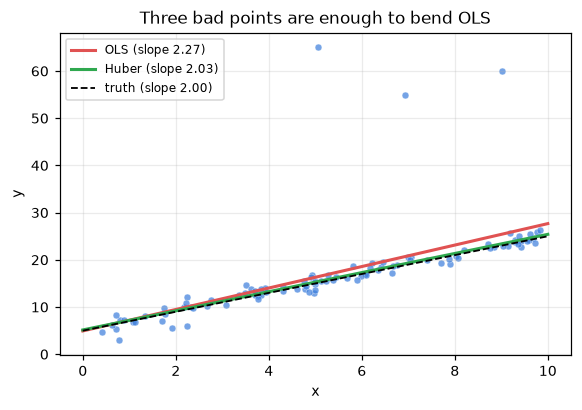

In [35]:
from sklearn.linear_model import HuberRegressor

rng = np.random.default_rng(4)
n = 100
x_o = rng.uniform(0, 10, n)
y_o = 2 * x_o + 5 + rng.normal(0, 1.2, n)
y_o[[10, 40, 75]] = [60, 55, 65]                    # three bad measurements

grid = np.linspace(0, 10, 100).reshape(-1, 1)
ols = LinearRegression().fit(x_o.reshape(-1, 1), y_o)
hub = HuberRegressor(epsilon=1.35).fit(x_o.reshape(-1, 1), y_o)

plt.figure(figsize=(6, 3.8))
plt.scatter(x_o, y_o, s=20, color=BLUE, alpha=0.7, edgecolor="w", linewidth=0.3)
plt.plot(grid, ols.predict(grid), color=RED, lw=2, label=f"OLS (slope {ols.coef_[0]:.2f})")
plt.plot(grid, hub.predict(grid), color=GREEN, lw=2, label=f"Huber (slope {hub.coef_[0]:.2f})")
plt.plot(grid, 2 * grid + 5, "k--", lw=1.2, label="truth (slope 2.00)")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(fontsize=8)
plt.title("Three bad points are enough to bend OLS")
plt.show()

---

# Part 8 — Feature engineering

A linear model can only draw straight lines *in the space you give it*. Feature engineering is the act of choosing a better space. It is where most of the accuracy on tabular problems comes from.

| Technique | What it buys you |
|---|---|
| **Polynomial features** | curvature: $x^2, x^3$ |
| **Interactions** | effects that depend on each other: $x_1 x_2$ |
| **Log / sqrt / Box-Cox** | tames skew and multiplicative relationships |
| **Binning** | lets a feature have an arbitrary step-shaped effect |
| **Splines** | smooth non-linearity without polynomial blow-up at the edges |
| **Cyclical (sin/cos)** | hours, months, angles, where 23 is next to 0 |
| **Ratios and differences** | encode domain knowledge directly |
| **Date parts** | year, month, weekday, is_holiday |
| **Aggregates** | group means, counts, "how many other orders from this customer" |

Two rules of thumb: **the number of interaction terms grows quadratically**, so pair polynomial expansion with regularization; and **domain knowledge beats brute force** — one well-chosen ratio usually outperforms a hundred automatic products.

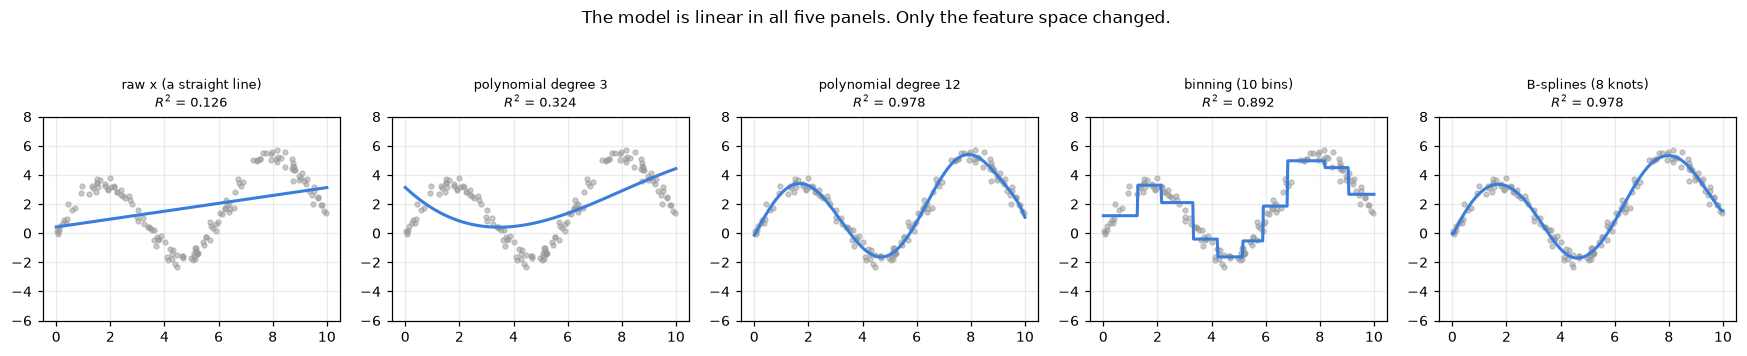

Degree 12 fits the training data best and oscillates wildly at the edges -
polynomials are badly behaved outside the data range. Splines are the safe choice:
they are local, so a wiggle in one region does not disturb another.


In [36]:
from sklearn.preprocessing import SplineTransformer, KBinsDiscretizer

# what different expansions can represent, on one wiggly function
rng = np.random.default_rng(7)
n = 150
x_fe = np.sort(rng.uniform(0, 10, n))
y_fe = np.sin(x_fe) * 3 + 0.3 * x_fe + rng.normal(0, 0.35, n)
Xfe = x_fe.reshape(-1, 1)
grid = np.linspace(0, 10, 400).reshape(-1, 1)

expansions = {
    "raw x (a straight line)": None,
    "polynomial degree 3": PolynomialFeatures(3, include_bias=False),
    "polynomial degree 12": PolynomialFeatures(12, include_bias=False),
    "binning (10 bins)": KBinsDiscretizer(n_bins=10, encode="onehot-dense", strategy="quantile"),
    "B-splines (8 knots)": SplineTransformer(n_knots=8, degree=3),
}

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for ax, (name, tr) in zip(axes, expansions.items()):
    steps = [] if tr is None else [("expand", tr)]
    model = Pipeline(steps + [("scale", StandardScaler()), ("m", Ridge(alpha=1e-6))])
    model.fit(Xfe, y_fe)
    ax.scatter(x_fe, y_fe, s=10, alpha=0.5, color="#999")
    ax.plot(grid, model.predict(grid), color=BLUE, lw=2)
    ax.set_ylim(-6, 8)
    ax.set_title(f"{name}\n$R^2$ = {model.score(Xfe, y_fe):.3f}", fontsize=8.5)
plt.suptitle("The model is linear in all five panels. Only the feature space changed.", y=1.06)
plt.tight_layout(); plt.show()

print("Degree 12 fits the training data best and oscillates wildly at the edges -")
print("polynomials are badly behaved outside the data range. Splines are the safe choice:")
print("they are local, so a wiggle in one region does not disturb another.")

without interaction term: test R2 = 0.8994
with    interaction term: test R2 = 0.9837


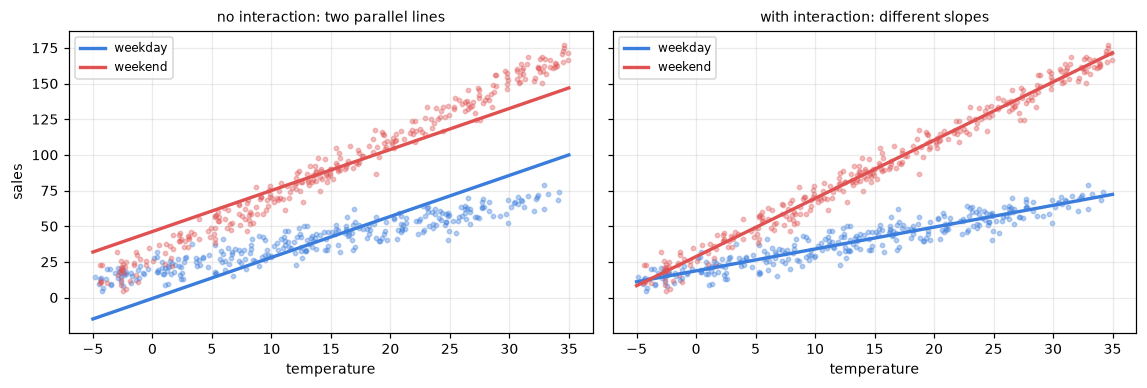


Without the x1*x2 term a linear model can only shift the line up or down per group.
The interaction lets each group have its own SLOPE.


In [37]:
# interactions: an effect that depends on another feature
rng = np.random.default_rng(8)
n = 600
temp = rng.uniform(-5, 35, n)
is_weekend = rng.integers(0, 2, n)
# ice-cream sales: temperature matters much more at the weekend
sales = 20 + 1.5 * temp + 10 * is_weekend + 2.5 * temp * is_weekend + rng.normal(0, 6, n)

X_int = np.c_[temp, is_weekend]
Xtr_i, Xte_i, ytr_i, yte_i = train_test_split(X_int, sales, test_size=0.3, random_state=0)

plain = LinearRegression().fit(Xtr_i, ytr_i)
inter = make_pipeline(PolynomialFeatures(2, interaction_only=True, include_bias=False),
                      LinearRegression()).fit(Xtr_i, ytr_i)

print(f"without interaction term: test R2 = {plain.score(Xte_i, yte_i):.4f}")
print(f"with    interaction term: test R2 = {inter.score(Xte_i, yte_i):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6), sharey=True)
g = np.linspace(-5, 35, 100)
for ax, model, t in [(axes[0], plain, "no interaction: two parallel lines"),
                     (axes[1], inter, "with interaction: different slopes")]:
    for wk, col, lbl in [(0, BLUE, "weekday"), (1, RED, "weekend")]:
        m = X_int[:, 1] == wk
        ax.scatter(temp[m], sales[m], s=8, alpha=0.35, color=col)
        ax.plot(g, model.predict(np.c_[g, np.full_like(g, wk)]), color=col, lw=2.2, label=lbl)
    ax.set_xlabel("temperature"); ax.set_title(t, fontsize=9); ax.legend(fontsize=8)
axes[0].set_ylabel("sales")
plt.tight_layout(); plt.show()

print("\nWithout the x1*x2 term a linear model can only shift the line up or down per group.")
print("The interaction lets each group have its own SLOPE.")

In [50]:
import numpy as np

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score


# ============================================================
# 1. Load data
# ============================================================

diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

feature_names = diabetes.feature_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Features:", feature_names)


# ============================================================
# 2. Train / Test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)


# ============================================================
# 3. Define preprocessing
# ============================================================

# All features in the diabetes dataset are numerical
numerical_features = list(range(X.shape[1]))

preprocessor = ColumnTransformer([
    (
        "num",
        StandardScaler(),
        numerical_features
    )
])


# ============================================================
# 4. Build pipeline
# ============================================================

pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", Ridge())
])


# ============================================================
# 5. Define hyperparameter grid
# ============================================================

param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}


# ============================================================
# 6. Grid Search + Cross Validation
# ============================================================

search = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    refit=True
)

search.fit(X_train, y_train)


# ============================================================
# 7. Best model
# ============================================================

print("\nBest parameters:")
print(search.best_params_)

print("\nBest CV RMSE:")
print(-search.best_score_)


# ============================================================
# 8. Evaluate on TEST set
# ============================================================

pred = search.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, pred))
test_r2 = r2_score(y_test, pred)

print("\nTest results:")
print(f"RMSE: {test_rmse:.3f}")
print(f"R2  : {test_r2:.3f}")


# ============================================================
# 9. Get the fitted transformer from the best pipeline
# ============================================================

best_pipe = search.best_estimator_

fitted_preprocessor = best_pipe.named_steps["preprocess"]

fitted_scaler = (
    fitted_preprocessor
    .named_transformers_["num"]
)


# ============================================================
# 10. Transform TRAIN and TEST manually
# ============================================================

X_train_scaled = fitted_scaler.transform(X_train)
X_test_scaled = fitted_scaler.transform(X_test)


print("\nTransformed data:")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)


# ============================================================
# 11. Compare statistics before and after scaling
# ============================================================

print("\nOriginal TRAIN feature means:")
print(X_train.mean(axis=0))

print("\nScaled TRAIN feature means:")
print(X_train_scaled.mean(axis=0))

print("\nOriginal TEST feature means:")
print(X_test.mean(axis=0))

print("\nScaled TEST feature means:")
print(X_test_scaled.mean(axis=0))


# ============================================================
# 12. Compare the first sample
# ============================================================

print("\nFirst TRAIN sample:")
print(X_train[0])

print("\nFirst TRAIN sample after scaling:")
print(X_train_scaled[0])

print("\nFirst TEST sample:")
print(X_test[0])

print("\nFirst TEST sample after scaling:")
print(X_test_scaled[0])

X shape: (442, 10)
y shape: (442,)
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Train shape: (353, 10)
Test shape : (89, 10)

Best parameters:
{'model__alpha': 10}

Best CV RMSE:
55.864483875531185

Test results:
RMSE: 53.626
R2  : 0.457

Transformed data:
X_train_scaled shape: (353, 10)
X_test_scaled shape : (89, 10)

Original TRAIN feature means:
[ 0.00144181  0.00018389  0.00173566  0.00117939 -0.00055551 -0.00080601
 -0.000989    0.00037655  0.00121606  0.00189101]

Scaled TRAIN feature means:
[-1.88706463e-17 -2.39028187e-17 -2.32737971e-17  3.00357787e-17
 -1.66690709e-17 -3.20800987e-17  1.76126032e-17  5.91280251e-17
 -9.98571701e-18  6.87992313e-18]

Original TEST feature means:
[-0.00571863 -0.00072937 -0.00688413 -0.0046778   0.00220332  0.00319687
  0.00392268 -0.00149352 -0.00482325 -0.00750029]

Scaled TEST feature means:
[-0.15475875 -0.0191956  -0.18259061 -0.1210162   0.0578151   0.08415825
  0.10455509 -0.03918665 -0.1264499  -0.19438961]

---

# Part 9 — Six challenge problems

Each one follows the same shape:

1. a dataset where the obvious approach does badly,
2. **a diagnosis** — how you would have noticed,
3. the fix, and the measured improvement.

The point is not the six specific tricks. It is the habit: *a linear model failing usually means the features are wrong, not that the model is too simple.*

## Challenge 1 — Time of day

**The task.** Predict the number of bicycles rented, from the hour of the day. Demand peaks in the morning and evening.

**The obvious approach.** Feed `hour` in as a number from 0 to 23.

NAIVE (hour as a number):  test R2 = 0.0451


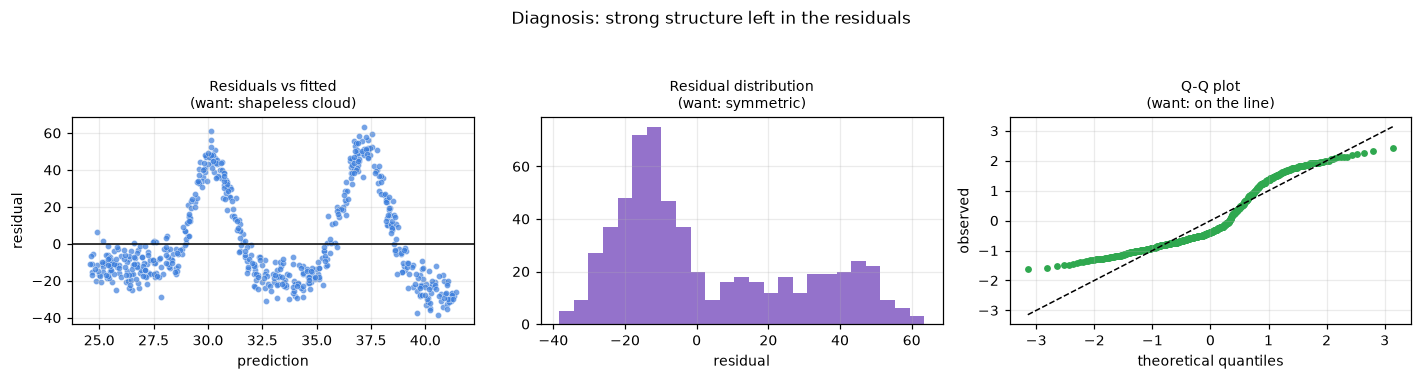

In [38]:
rng = np.random.default_rng(10)
n = 2000
hour = rng.integers(0, 24, n)
minute = rng.integers(0, 60, n)
t = hour + minute / 60
# two commuting peaks plus a low overnight baseline
demand = (60 * np.exp(-((t - 8) ** 2) / 3) + 75 * np.exp(-((t - 18) ** 2) / 4)
          + 15 + rng.normal(0, 6, n))

X_h = t.reshape(-1, 1)
Xtr_h, Xte_h, ytr_h, yte_h = train_test_split(X_h, demand, test_size=0.3, random_state=0)

naive = LinearRegression().fit(Xtr_h, ytr_h)
print(f"NAIVE (hour as a number):  test R2 = {naive.score(Xte_h, yte_h):.4f}")
residual_plots(yte_h, naive.predict(Xte_h), title="Diagnosis: strong structure left in the residuals")

**Diagnosis.** Two problems, both visible in the plots. First, the relationship is not monotonic, so a straight line cannot follow it. Second — and more subtly — the encoding is *wrong at the boundary*: hour 23 and hour 0 are one hour apart in reality, but 23 units apart in the feature.

**The fix.** Represent the hour as a point on a circle:

$$x_{\sin} = \sin\!\left(\frac{2\pi \cdot h}{24}\right), \qquad x_{\cos} = \cos\!\left(\frac{2\pi \cdot h}{24}\right)$$

Now 23:00 and 00:00 are genuinely adjacent. Then add splines (or harmonics) so the model can express the two peaks. The same trick applies to month, day of week, wind direction and any angle.

encoding of the hour                 test R2
---------------------------------------------
raw hour                              0.0451
one-hot per hour (24 dummies)         0.9158
sin/cos (1 harmonic)                  0.1085
sin/cos (3 harmonics)                 0.8574
periodic splines                      0.9288


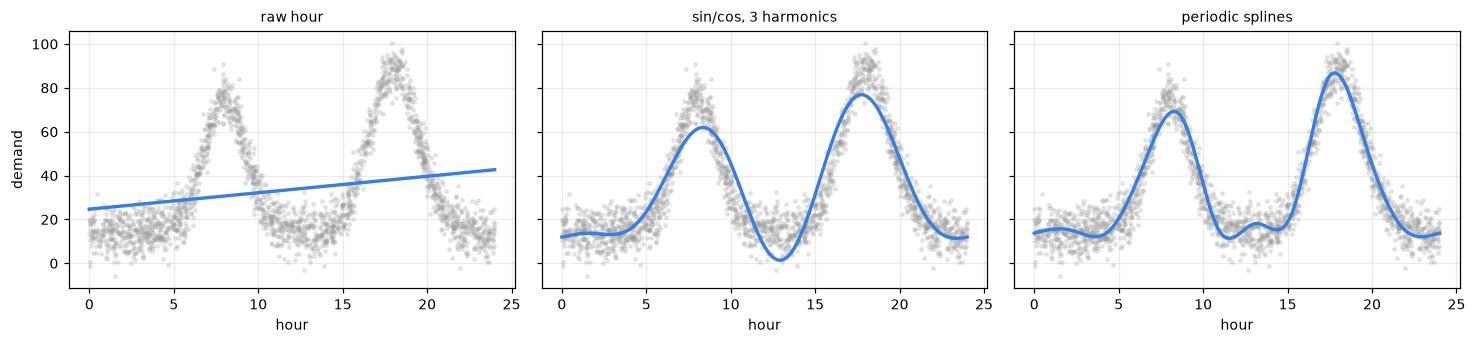


R2 went from 0.045 to 0.929 - same model, better features.


In [39]:
def cyclical(t, period=24):
    return np.c_[np.sin(2 * np.pi * t / period), np.cos(2 * np.pi * t / period)]


approaches = {
    "raw hour":                         X_h,
    "one-hot per hour (24 dummies)":    OneHotEncoder(sparse_output=False).fit_transform(
                                            np.floor(t).reshape(-1, 1)),
    "sin/cos (1 harmonic)":             cyclical(t),
    "sin/cos (3 harmonics)":            np.hstack([cyclical(t, 24 / k) for k in (1, 2, 3)]),
    "periodic splines":                 SplineTransformer(
                                            n_knots=12, degree=3, extrapolation="periodic"
                                        ).fit_transform((t % 24).reshape(-1, 1)),
}

print(f"{'encoding of the hour':<34} {'test R2':>9}")
print("-" * 45)
results_c1 = {}
for name, Xa in approaches.items():
    Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(Xa, demand, test_size=0.3, random_state=0)
    m = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(Xa_tr, ya_tr)
    results_c1[name] = m.score(Xa_te, ya_te)
    print(f"{name:<34} {results_c1[name]:>9.4f}")

# show what each encoding can express
gt = np.linspace(0, 24, 400)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.2), sharey=True)
for ax, (name, build) in zip(axes, [("raw hour", lambda z: z.reshape(-1, 1)),
                                    ("sin/cos, 3 harmonics",
                                     lambda z: np.hstack([cyclical(z, 24 / k) for k in (1, 2, 3)])),
                                    ("periodic splines",
                                     lambda z: SplineTransformer(n_knots=12, degree=3,
                                        extrapolation="periodic").fit(
                                        (t % 24).reshape(-1, 1)).transform((z % 24).reshape(-1, 1)))]):
    Xa = build(t)
    m = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(Xa, demand)
    ax.scatter(t, demand, s=5, alpha=0.2, color="#999")
    ax.plot(gt, m.predict(build(gt)), color=BLUE, lw=2.2)
    ax.set_xlabel("hour"); ax.set_title(name, fontsize=9)
axes[0].set_ylabel("demand")
plt.tight_layout(); plt.show()

print(f"\nR2 went from {results_c1['raw hour']:.3f} to "
      f"{max(results_c1.values()):.3f} - same model, better features.")

## Challenge 2 — A skewed, multiplicative target

**The task.** Predict house prices. Prices are positive, right-skewed, and the *percentage* error is what matters — a 50 million error on a 100 million house is a disaster; on a 5 billion house it is noise.

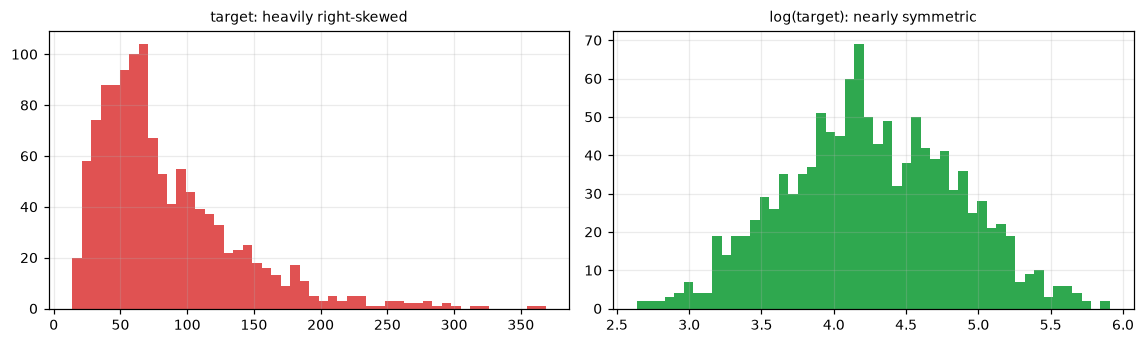

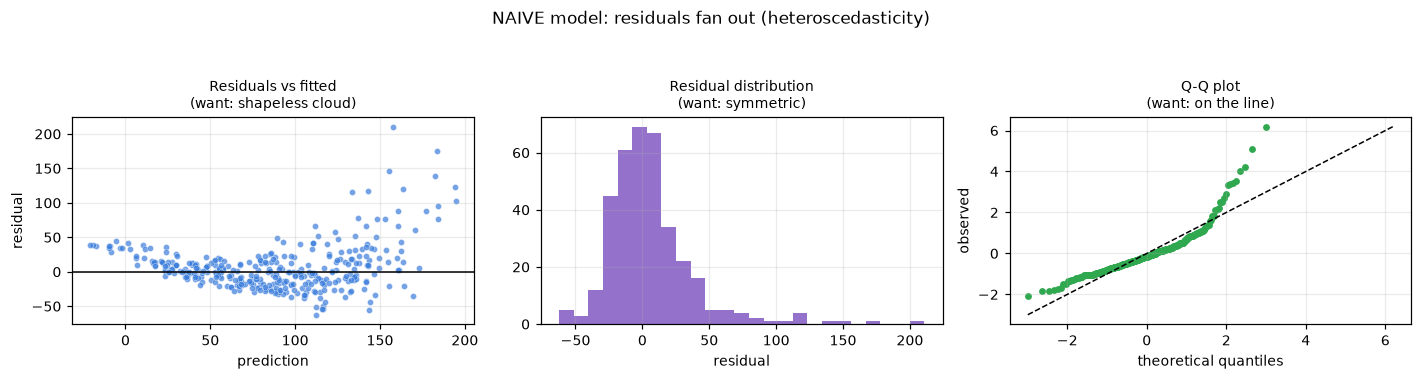

In [40]:
rng = np.random.default_rng(11)
n = 1200
area = rng.uniform(40, 300, n)
rooms = rng.integers(1, 6, n)
age = rng.uniform(0, 40, n)
# a MULTIPLICATIVE process with proportional noise: exactly what log-transforms fix
price = (np.exp(3.2 + 0.006 * area + 0.15 * rooms - 0.02 * age)
         * rng.lognormal(0, 0.25, n))

X_p = np.c_[area, rooms, age]
Xtr_p, Xte_p, ytr_p, yte_p = train_test_split(X_p, price, test_size=0.3, random_state=0)

base = make_pipeline(StandardScaler(), LinearRegression()).fit(Xtr_p, ytr_p)
pred_base = base.predict(Xte_p)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.2))
axes[0].hist(price, bins=50, color=RED); axes[0].set_title("target: heavily right-skewed", fontsize=9)
axes[1].hist(np.log(price), bins=50, color=GREEN); axes[1].set_title("log(target): nearly symmetric", fontsize=9)
plt.tight_layout(); plt.show()

residual_plots(yte_p, pred_base, title="NAIVE model: residuals fan out (heteroscedasticity)")

**Diagnosis.** The target histogram is heavily skewed, and the residual plot fans out — the errors grow with the prediction. Both point to the same thing: the process is **multiplicative**, but we are fitting an **additive** model.

**The fix.** Fit $\log y$ instead. A sum in log-space is a product in the original space, which matches the data-generating process; and proportional noise becomes constant-variance noise. Then invert with `exp` when predicting.

Two details that people get wrong:

* Use `np.log1p` / `np.expm1` if the target can be zero.
* **Report the metric in the original units.** An $R^2$ computed in log-space is not comparable to one computed on prices. `TransformedTargetRegressor` handles the round trip for you.

model                              R2         RMSE    MAPE %
------------------------------------------------------------
naive (fit on price)           0.6979         33.6      27.9
fit on log(price)              0.8019         27.2      19.4


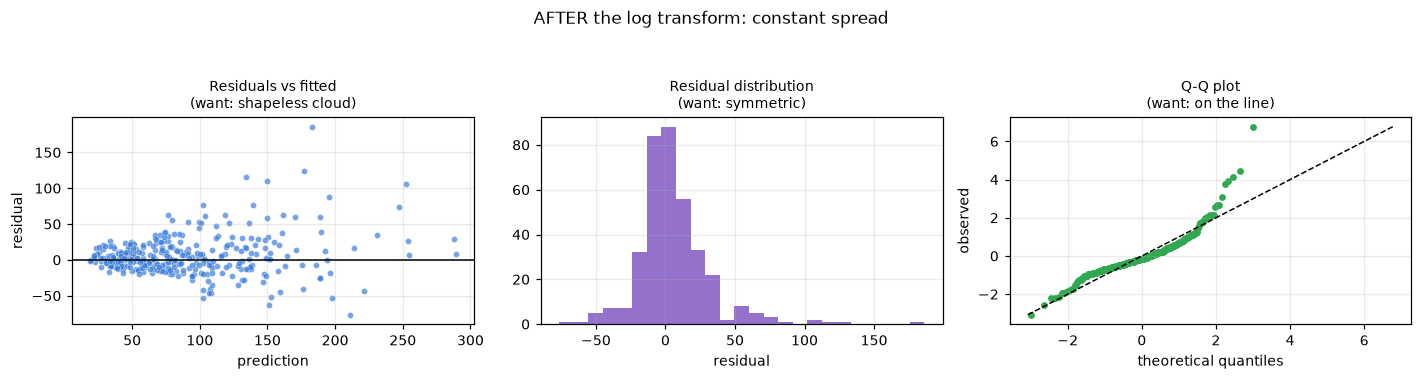

The RMSE improvement is modest, but MAPE - the error people actually feel -
improves a lot, and the model is no longer systematically wrong for cheap houses.


In [41]:
from sklearn.compose import TransformedTargetRegressor

log_model = TransformedTargetRegressor(
    regressor=make_pipeline(StandardScaler(), LinearRegression()),
    func=np.log, inverse_func=np.exp,
).fit(Xtr_p, ytr_p)
pred_log = log_model.predict(Xte_p)

def mape(y, p):
    return float(np.mean(np.abs((p - y) / y)) * 100)

print(f"{'model':<28} {'R2':>8} {'RMSE':>12} {'MAPE %':>9}")
print("-" * 60)
for name, p in [("naive (fit on price)", pred_base), ("fit on log(price)", pred_log)]:
    print(f"{name:<28} {r2_score(yte_p, p):>8.4f} "
          f"{np.sqrt(mean_squared_error(yte_p, p)):>12.1f} {mape(yte_p, p):>9.1f}")

residual_plots(yte_p, pred_log, title="AFTER the log transform: constant spread")

print("The RMSE improvement is modest, but MAPE - the error people actually feel -")
print("improves a lot, and the model is no longer systematically wrong for cheap houses.")

## Challenge 3 — An effect that only exists in combination

**The task.** Two treatments, A and B. Each one alone helps a lot. Given **together** they interfere and cancel out — a real phenomenon in pharmacology, called an antagonistic drug interaction.

The consequence is that neither column, on its own, carries any signal at all: patients given A recover about as often as patients not given A, because half of them also received B.

In [43]:
rng = np.random.default_rng(12)
n = 1500
treat_A = rng.integers(0, 2, n)
treat_B = rng.integers(0, 2, n)
age = rng.uniform(20, 70, n)                        # an irrelevant covariate
# recovery is likely when EXACTLY ONE treatment was given
p_recover = 0.10 + 0.75 * ((treat_A + treat_B) == 1)
recovered = (rng.random(n) < p_recover).astype(int)

X_x = np.c_[treat_A, treat_B, age]
Xtr_x, Xte_x, ytr_x, yte_x = train_test_split(X_x, recovered, test_size=0.3,
                                              random_state=0, stratify=recovered)

print("recovery rate by group:")
for a in (0, 1):
    for b in (0, 1):
        m = (treat_A == a) & (treat_B == b)
        print(f"   A={a} B={b}:  {recovered[m].mean()*100:5.1f}%   (n={m.sum()})")

print("\nmarginal rates:")
for name, col in [("A given", treat_A), ("B given", treat_B)]:
    print(f"   {name:<9}: yes {recovered[col == 1].mean()*100:5.1f}%   "
          f"no {recovered[col == 0].mean()*100:5.1f}%")
print("\nIdentical marginals. Each feature alone is worthless; only their")
print("combination predicts anything. This is the XOR problem.")

naive_c = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(Xtr_x, ytr_x)
print(f"\nNAIVE logistic regression: test AUC = "
      f"{roc_auc_score(yte_x, naive_c.predict_proba(Xte_x)[:, 1]):.4f}   (0.5 = coin flip)")

recovery rate by group:
   A=0 B=0:    9.7%   (n=361)
   A=0 B=1:   82.2%   (n=366)
   A=1 B=0:   84.2%   (n=386)
   A=1 B=1:   10.3%   (n=387)

marginal rates:
   A given  : yes  47.2%   no  46.2%
   B given  : yes  45.3%   no  48.2%

Identical marginals. Each feature alone is worthless; only their
combination predicts anything. This is the XOR problem.

NAIVE logistic regression: test AUC = 0.5232   (0.5 = coin flip)


**Diagnosis.** An AUC of 0.5 with features you are confident are relevant is the signature of an interaction. A quick check: cross-tabulate the target by pairs of categorical features, as we did above. If the cell-by-cell pattern is not explained by the row and column margins, there is an interaction.

**The fix.** Add the product term. `PolynomialFeatures(2)` generates $x_1^2, x_2^2$ and $x_1x_2$; the last one is what we need. For binary features $x^2 = x$, so effectively we are adding exactly one new column.

model                                  AUC   accuracy
------------------------------------------------------
raw features                        0.5232     0.5333
+ interaction terms (degree 2)      0.8811     0.8778


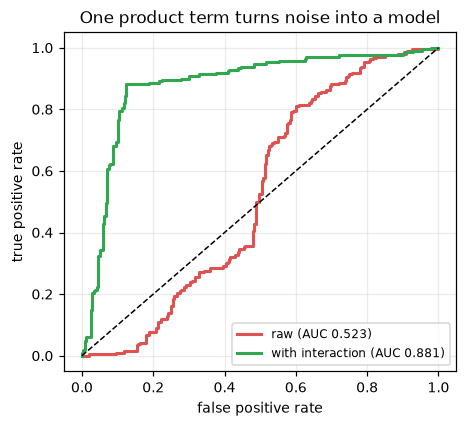

From a coin flip to a strong classifier, by adding a single column.
Lesson: before concluding 'a linear model is too weak for this problem',
ask whether the effect you are looking for is even representable in your features.


In [44]:
fixed_c = make_pipeline(
    PolynomialFeatures(2, include_bias=False),      # adds the A*B product
    StandardScaler(),
    LogisticRegression(C=1.0, max_iter=5000),
).fit(Xtr_x, ytr_x)

p_naive = naive_c.predict_proba(Xte_x)[:, 1]
p_fixed = fixed_c.predict_proba(Xte_x)[:, 1]

print(f"{'model':<34} {'AUC':>7} {'accuracy':>10}")
print("-" * 54)
for name, p, m in [("raw features", p_naive, naive_c),
                   ("+ interaction terms (degree 2)", p_fixed, fixed_c)]:
    print(f"{name:<34} {roc_auc_score(yte_x, p):>7.4f} {m.score(Xte_x, yte_x):>10.4f}")

fpr1, tpr1 = roc_curve(yte_x, p_naive)
fpr2, tpr2 = roc_curve(yte_x, p_fixed)
plt.figure(figsize=(4.6, 4))
plt.plot(fpr1, tpr1, color=RED, lw=2, label=f"raw (AUC {auc(fpr1, tpr1):.3f})")
plt.plot(fpr2, tpr2, color=GREEN, lw=2, label=f"with interaction (AUC {auc(fpr2, tpr2):.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("false positive rate"); plt.ylabel("true positive rate")
plt.legend(fontsize=8); plt.title("One product term turns noise into a model")
plt.show()

print("From a coin flip to a strong classifier, by adding a single column.")
print("Lesson: before concluding 'a linear model is too weak for this problem',")
print("ask whether the effect you are looking for is even representable in your features.")

## Challenge 4 — More features than samples

**The task.** 80 patients, 500 gene-expression measurements, and only a handful of genes actually matter. This shape — wide and short — is completely normal in biology, chemistry and finance.

Ordinary least squares cannot even be computed uniquely here: with $n > m$ there are infinitely many weight vectors that fit the training data **perfectly**.

In [45]:
rng = np.random.default_rng(13)
m_s, n_f, k_true = 80, 500, 6
Xg = rng.normal(size=(m_s, n_f))
true_w = np.zeros(n_f)
true_w[:k_true] = [4, -3.5, 3, -2.5, 2, -2]
yg = Xg @ true_w + rng.normal(0, 1.0, m_s)

Xg_tr, Xg_te, yg_tr, yg_te = train_test_split(Xg, yg, test_size=0.35, random_state=0)
print(f"train: {Xg_tr.shape[0]} samples, {Xg_tr.shape[1]} features")

ols_w = LinearRegression().fit(Xg_tr, yg_tr)
print(f"\nOLS train R2: {ols_w.score(Xg_tr, yg_tr):.4f}   <- flawless")
print(f"OLS test  R2: {ols_w.score(Xg_te, yg_te):.4f}   <- almost useless")
print("\nA perfect training score next to a near-zero test score is the clearest")
print("signature there is of a model that memorized instead of learning.")

train: 52 samples, 500 features

OLS train R2: 1.0000   <- flawless
OLS test  R2: 0.1446   <- almost useless

A perfect training score next to a near-zero test score is the clearest
signature there is of a model that memorized instead of learning.


model           train R2   test R2   non-zero   real genes in top 6
----------------------------------------------------------------------
OLS                1.000     0.113        500                   4/6
Ridge (CV)         0.611    -0.096        500                   3/6
Lasso (CV)         1.000     0.957         61                   6/6
ElasticNet         1.000     0.957         61                   6/6


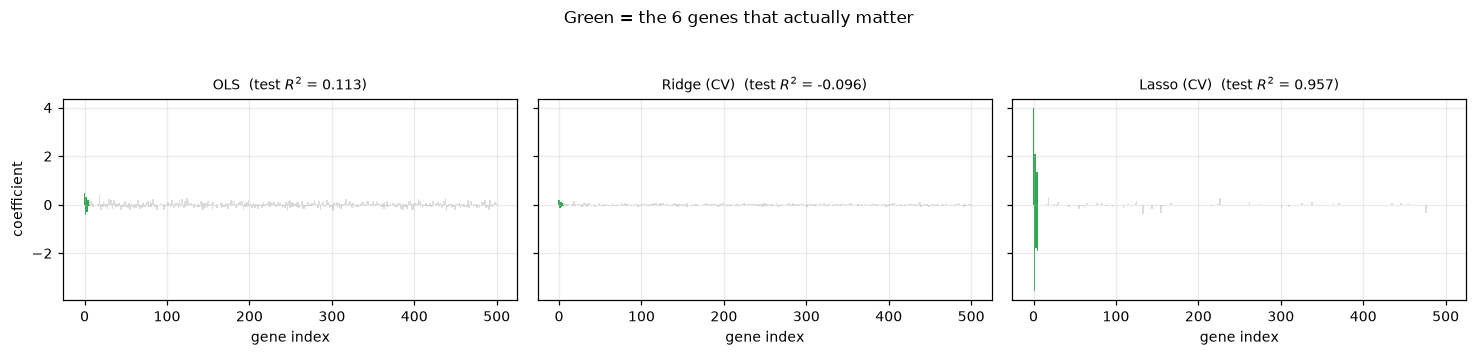


Note that Ridge does NOT rescue this. It shrinks all 500 coefficients a
little, spreading the signal thinly across hundreds of noise genes - here it
scores no better than predicting the mean. When the truth is SPARSE, L2 is
the wrong prior and L1 is the right one.

Lasso also does something no other model here can: it names the genes.
When you have to tell a biologist which six to investigate, that is the point.


In [46]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

models = {
    "OLS":         make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge (CV)":  make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 4, 40))),
    "Lasso (CV)":  make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=0, max_iter=20000)),
    "ElasticNet":  make_pipeline(StandardScaler(),
                                 ElasticNetCV(l1_ratio=[.3, .5, .7, .9, .95, 1.0], cv=5,
                                              random_state=0, max_iter=20000)),
}

print(f"{'model':<14} {'train R2':>9} {'test R2':>9} {'non-zero':>10} {'real genes in top 6':>21}")
print("-" * 70)
fitted = {}
for name, mdl in models.items():
    mdl.fit(Xg_tr, yg_tr)
    fitted[name] = mdl
    coef = mdl[-1].coef_
    nz = int((np.abs(coef) > 1e-8).sum())
    top6 = np.argsort(-np.abs(coef))[:k_true]        # the 6 genes this model points at
    found = int((top6 < k_true).sum())
    print(f"{name:<14} {mdl.score(Xg_tr, yg_tr):>9.3f} {mdl.score(Xg_te, yg_te):>9.3f} "
          f"{nz:>10} {f'{found}/{k_true}':>21}")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3), sharey=True)
for ax, name in zip(axes, ["OLS", "Ridge (CV)", "Lasso (CV)"]):
    c = fitted[name][-1].coef_
    ax.bar(range(n_f), c, color=[GREEN if i < k_true else "#ddd" for i in range(n_f)], width=2)
    ax.set_title(f"{name}  (test $R^2$ = {fitted[name].score(Xg_te, yg_te):.3f})", fontsize=9)
    ax.set_xlabel("gene index")
axes[0].set_ylabel("coefficient")
plt.suptitle("Green = the 6 genes that actually matter", y=1.06)
plt.tight_layout(); plt.show()

print("\nNote that Ridge does NOT rescue this. It shrinks all 500 coefficients a")
print("little, spreading the signal thinly across hundreds of noise genes - here it")
print("scores no better than predicting the mean. When the truth is SPARSE, L2 is")
print("the wrong prior and L1 is the right one.")
print("\nLasso also does something no other model here can: it names the genes.")
print("When you have to tell a biologist which six to investigate, that is the point.")

## Challenge 5 — Severe class imbalance

**The task.** Fraud detection: 1.5% of transactions are fraudulent. The naive model reaches 98.5% accuracy by never predicting fraud at all.

In [47]:
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score

rng = np.random.default_rng(14)
n = 12000
fraud_rate = 0.015
y_f = (rng.random(n) < fraud_rate).astype(int)
X_f = rng.normal(size=(n, 6))
X_f[y_f == 1] += np.array([1.1, -0.9, 0.7, 0.0, 0.0, 0.5])      # fraud shifts some features

Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(X_f, y_f, test_size=0.3,
                                              random_state=0, stratify=y_f)
print(f"fraud in the training set: {yf_tr.mean()*100:.2f}%  ({yf_tr.sum()} of {len(yf_tr)})")

plain = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(Xf_tr, yf_tr)
pred_plain = plain.predict(Xf_te)
print(f"\nNAIVE model accuracy: {accuracy_score(yf_te, pred_plain):.4f}  <- looks superb")
print(f"fraud cases caught  : {int(((pred_plain == 1) & (yf_te == 1)).sum())} "
      f"out of {int(yf_te.sum())}")
print(f"recall              : {classification_metrics(yf_te, pred_plain)['recall']:.3f}")
print("\nIt achieved a high score by essentially never raising an alarm.")

fraud in the training set: 1.45%  (122 of 8400)

NAIVE model accuracy: 0.9858  <- looks superb
fraud cases caught  : 1 out of 52
recall              : 0.019

It achieved a high score by essentially never raising an alarm.


**Diagnosis.** Accuracy is the wrong metric, and the default threshold of 0.5 is the wrong decision rule. With a 1.5% base rate, the model rarely assigns a probability above 0.5 to *anything*, so it predicts "not fraud" almost always.

**Three fixes, best applied together:**

1. **Change the metric.** Use PR-AUC (average precision) and recall at a fixed precision. ROC-AUC is over-optimistic on rare classes.
2. **`class_weight="balanced"`** — weight each class inversely to its frequency in the loss, so the rare class stops being ignored.
3. **Tune the threshold** on validation data, using the actual costs. If a missed fraud costs 100× a false alarm, encode that.

Resampling (SMOTE, undersampling) is a fourth option, but it distorts the probabilities and often adds nothing beyond class weights for a linear model. Try weights first.

setup                                        recall  precision      F1     cost
--------------------------------------------------------------------------------
plain, threshold 0.5                          0.019      1.000   0.038     2550
class_weight='balanced', threshold 0.5        0.808      0.054   0.102     1229
plain, tuned threshold 0.026                  0.750      0.083   0.149     1083

ROC AUC        : 0.9086   <- looks fine either way
Average precision: 0.1831   <- the honest number
(a random model would score 0.0144 on average precision)


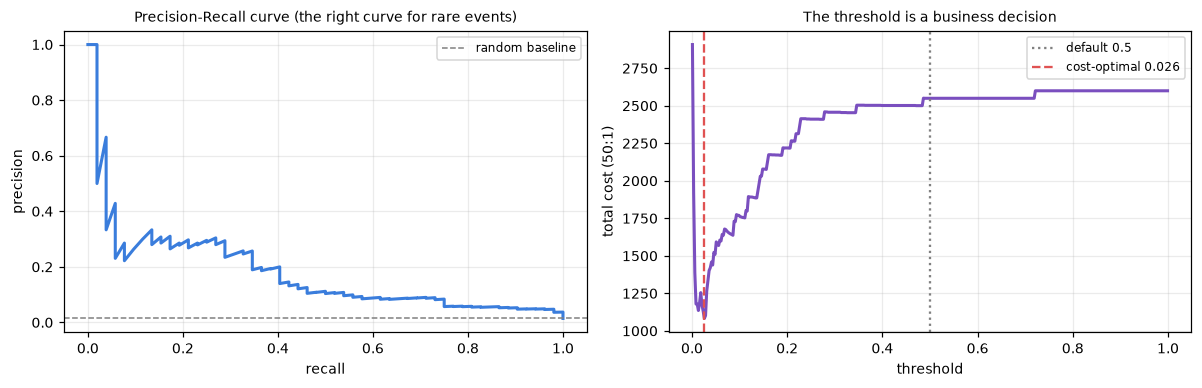

In [48]:
weighted = make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=2000, class_weight="balanced")).fit(Xf_tr, yf_tr)

p_plain = plain.predict_proba(Xf_te)[:, 1]
p_weight = weighted.predict_proba(Xf_te)[:, 1]

# tune the threshold for a cost model: one missed fraud costs as much as 50 false alarms
COST_FN, COST_FP = 50, 1
ths = np.linspace(0.001, 0.999, 400)
costs = [((yf_te == 1) & (p_plain < t)).sum() * COST_FN +
         ((yf_te == 0) & (p_plain >= t)).sum() * COST_FP for t in ths]
best_t = ths[int(np.argmin(costs))]

print(f"{'setup':<42} {'recall':>8} {'precision':>10} {'F1':>7} {'cost':>8}")
print("-" * 80)
for name, p, t in [("plain, threshold 0.5", p_plain, 0.5),
                   ("class_weight='balanced', threshold 0.5", p_weight, 0.5),
                   (f"plain, tuned threshold {best_t:.3f}", p_plain, best_t)]:
    pr = (p >= t).astype(int)
    mm = classification_metrics(yf_te, pr)
    cost = ((yf_te == 1) & (pr == 0)).sum() * COST_FN + ((yf_te == 0) & (pr == 1)).sum() * COST_FP
    print(f"{name:<42} {mm['recall']:>8.3f} {mm['precision']:>10.3f} {mm['f1']:>7.3f} {cost:>8.0f}")

print(f"\nROC AUC        : {roc_auc_score(yf_te, p_plain):.4f}   <- looks fine either way")
print(f"Average precision: {average_precision_score(yf_te, p_plain):.4f}   <- the honest number")
print(f"(a random model would score {yf_te.mean():.4f} on average precision)")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
prec, rec_, _ = precision_recall_curve(yf_te, p_plain)
axes[0].plot(rec_, prec, color=BLUE, lw=2)
axes[0].axhline(yf_te.mean(), ls="--", color="gray", lw=1, label="random baseline")
axes[0].set_xlabel("recall"); axes[0].set_ylabel("precision"); axes[0].legend(fontsize=8)
axes[0].set_title("Precision-Recall curve (the right curve for rare events)", fontsize=9)

axes[1].plot(ths, costs, color=PURPLE, lw=2)
axes[1].axvline(0.5, ls=":", color="gray", label="default 0.5")
axes[1].axvline(best_t, ls="--", color=RED, label=f"cost-optimal {best_t:.3f}")
axes[1].set_xlabel("threshold"); axes[1].set_ylabel(f"total cost ({COST_FN}:{COST_FP})")
axes[1].legend(fontsize=8); axes[1].set_title("The threshold is a business decision", fontsize=9)
plt.tight_layout(); plt.show()

## Challenge 6 — High-cardinality categories, and how target encoding goes wrong

**The task.** Predict delivery time from the postcode. There are 1200 postcodes and only 4000 rows, so one-hot encoding creates 1200 columns — more columns than we have rows per category.

**Target encoding** replaces each category with the mean target for that category — one column instead of 300. It is powerful and it is the most common source of silent data leakage in applied machine learning.

In [49]:
rng = np.random.default_rng(15)
n_zip, n = 1200, 4000
zip_effect = rng.normal(0, 6, n_zip)
zips = rng.integers(0, n_zip, n)
distance = rng.uniform(1, 30, n)
delivery = 20 + 0.8 * distance + zip_effect[zips] + rng.normal(0, 5, n)

idx_tr, idx_te = train_test_split(np.arange(n), test_size=0.3, random_state=0)

def naive_target_encode(zips_tr, y_tr, zips_all, prior):
    """WRONG: each row's own target contributes to its own encoding."""
    means = pd.Series(y_tr).groupby(zips_tr).mean()
    return pd.Series(zips_all).map(means).fillna(prior).to_numpy()

def smoothed_oof_encode(zips_tr, y_tr, zips_te, k=5, smoothing=20, seed=0):
    """RIGHT: out-of-fold encoding for the training rows, smoothed towards the global mean."""
    prior = y_tr.mean()
    enc_tr = np.zeros(len(y_tr))
    for tr_i, va_i in KFold(k, shuffle=True, random_state=seed).split(y_tr):
        g = pd.DataFrame({"z": zips_tr[tr_i], "y": y_tr[tr_i]}).groupby("z")["y"]
        stats = pd.DataFrame({"mean": g.mean(), "count": g.count()})
        sm = (stats["mean"] * stats["count"] + prior * smoothing) / (stats["count"] + smoothing)
        enc_tr[va_i] = pd.Series(zips_tr[va_i]).map(sm).fillna(prior).to_numpy()
    g = pd.DataFrame({"z": zips_tr, "y": y_tr}).groupby("z")["y"]
    stats = pd.DataFrame({"mean": g.mean(), "count": g.count()})
    sm = (stats["mean"] * stats["count"] + prior * smoothing) / (stats["count"] + smoothing)
    enc_te = pd.Series(zips_te).map(sm).fillna(prior).to_numpy()
    return enc_tr, enc_te


ytr_z, yte_z = delivery[idx_tr], delivery[idx_te]
d_tr, d_te = distance[idx_tr], distance[idx_te]
z_tr, z_te = zips[idx_tr], zips[idx_te]

results = {}

# A: ignore the postcode entirely
m = LinearRegression().fit(d_tr.reshape(-1, 1), ytr_z)
results["drop the postcode"] = (m.score(d_tr.reshape(-1, 1), ytr_z),
                                m.score(d_te.reshape(-1, 1), yte_z))

# B: one-hot, 300 columns
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore").fit(z_tr.reshape(-1, 1))
A_tr = np.c_[d_tr, ohe.transform(z_tr.reshape(-1, 1))]
A_te = np.c_[d_te, ohe.transform(z_te.reshape(-1, 1))]
m = make_pipeline(StandardScaler(), Ridge(alpha=10)).fit(A_tr, ytr_z)
results["one-hot (1200 columns)"] = (m.score(A_tr, ytr_z), m.score(A_te, yte_z))

# C: naive target encoding - looks amazing in training, fails on test
e_tr = naive_target_encode(z_tr, ytr_z, z_tr, ytr_z.mean())
e_te = naive_target_encode(z_tr, ytr_z, z_te, ytr_z.mean())
m = LinearRegression().fit(np.c_[d_tr, e_tr], ytr_z)
results["target encoding (LEAKY)"] = (m.score(np.c_[d_tr, e_tr], ytr_z),
                                      m.score(np.c_[d_te, e_te], yte_z))

# D: out-of-fold, smoothed target encoding
e_tr2, e_te2 = smoothed_oof_encode(z_tr, ytr_z, z_te)
m = LinearRegression().fit(np.c_[d_tr, e_tr2], ytr_z)
results["target encoding (out-of-fold)"] = (m.score(np.c_[d_tr, e_tr2], ytr_z),
                                            m.score(np.c_[d_te, e_te2], yte_z))

print(f"{'approach':<34} {'train R2':>9} {'test R2':>9} {'gap':>8}")
print("-" * 63)
for k, (tr, te) in results.items():
    print(f"{k:<34} {tr:>9.4f} {te:>9.4f} {tr-te:>8.4f}")

print(f"\nrows per postcode in the training set: {len(idx_tr)/n_zip:.1f}")
print("\nRead the GAP column. The leaky encoder trains at 0.76 and tests at 0.49 -")
print("with only ~2 rows per postcode, each row's own target dominates its own")
print("feature, so the training score is pure fantasy - and the honest test score")
print("is barely better than throwing the postcode away entirely.")
print("\nThe out-of-fold version replaces 1200 columns with ONE and still captures")
print("most of the postcode effect, with a train-test gap of essentially zero.")
print("One-hot + Ridge scores slightly higher here - target encoding is about")
print("compressing high cardinality, not about beating one-hot on small problems.")

approach                            train R2   test R2      gap
---------------------------------------------------------------
drop the postcode                     0.4229    0.4400  -0.0171
one-hot (1200 columns)                0.8482    0.6327   0.2155
target encoding (LEAKY)               0.7631    0.4931   0.2700
target encoding (out-of-fold)         0.5454    0.5997  -0.0543

rows per postcode in the training set: 2.3

Read the GAP column. The leaky encoder trains at 0.76 and tests at 0.49 -
with only ~2 rows per postcode, each row's own target dominates its own
feature, so the training score is pure fantasy - and the honest test score
is barely better than throwing the postcode away entirely.

The out-of-fold version replaces 1200 columns with ONE and still captures
most of the postcode effect, with a train-test gap of essentially zero.
One-hot + Ridge scores slightly higher here - target encoding is about
compressing high cardinality, not about beating one-hot on small problems

> **The general rule behind Challenge 6:** any transformation that uses the **target** must be fitted inside the cross-validation fold, never on the full dataset. Target encoding, feature selection by correlation with $y$, over/under-sampling, and outlier removal based on residuals are all in this category. Scikit-learn's `TargetEncoder` implements the out-of-fold scheme and belongs inside a `Pipeline`.

---

# Part 10 — A working checklist

The order in which to actually do this on a new tabular problem.

### 1. Before modelling
- [ ] Split off a **test set** and do not touch it again until the end.
- [ ] Plot every feature's distribution and its relationship with the target.
- [ ] Count missing values per column. Ask *why* they are missing.
- [ ] Check the target: skewed? bounded? imbalanced? outliers?
- [ ] Decide the metric **before** you see any results, based on what the errors cost.

### 2. Baseline
- [ ] Predict the mean (regression) or the majority class (classification). Every later model must beat this.
- [ ] Fit a plain linear/logistic regression on the raw features inside a `Pipeline`.
- [ ] Set up cross-validation: `StratifiedKFold` for classification, `TimeSeriesSplit` for time.

### 3. Diagnose
- [ ] **Plot residuals vs fitted.** Curvature → non-linearity. Fanning → transform the target.
- [ ] Compare train and validation scores. Big gap → overfitting. Both bad → underfitting.
- [ ] Check VIF or a correlation heatmap for near-duplicate features.
- [ ] For classification: look at the confusion matrix, not just accuracy.

### 4. Improve — roughly in order of return on effort
- [ ] Scale the features (almost always).
- [ ] Fix the target: log-transform if positive and skewed.
- [ ] Encode categories properly; add missing-value indicators.
- [ ] Encode cyclical features with sin/cos.
- [ ] Add domain-driven features: ratios, differences, aggregates.
- [ ] Add splines or polynomials for non-linear relationships.
- [ ] Add interactions where the domain suggests them.
- [ ] Regularize, and tune $\lambda$ / $C$ by cross-validation.
- [ ] For classification: fix the class weights, then tune the threshold on the cost.

### 5. Before you ship
- [ ] Every transformation is inside the `Pipeline`. No `fit` ever saw the test set.
- [ ] Evaluate on the test set **once**.
- [ ] Sanity-check the coefficient signs against domain knowledge.
- [ ] Ask what the model does with inputs outside the training range.

## Summary

| Concept | Linear regression | Logistic regression |
|---|---|---|
| Predicts | a number | a probability |
| Model | $\mathbf{w}^\top\mathbf{x} + b$ | $\sigma(\mathbf{w}^\top\mathbf{x} + b)$ |
| Loss | mean squared error | binary cross entropy |
| Derivation of the loss | Gaussian noise → maximum likelihood | Bernoulli labels → maximum likelihood |
| Closed form | yes, the normal equation | no |
| Gradient | $\frac{2}{m}X^\top(\hat y - y)$ | $\frac{1}{m}X^\top(\hat y - y)$ |
| Coefficient means | change in $y$ per unit | change in **log-odds** per unit; $e^{w}$ multiplies the odds |
| Main metrics | RMSE, MAE, $R^2$ | AUC, precision/recall, F1, log-loss |
| Regularized versions | Ridge, Lasso, Elastic Net | the same penalties, via `C` |

### The three things worth remembering

1. **A linear model is only linear in the space you give it.** Every non-linearity in this notebook was solved by changing the features, not the model.
2. **Preprocessing is not a chore, it is where the accuracy is.** Scaling, target transforms, encodings and threshold choice moved the numbers more than any algorithm swap would have.
3. **Anything fitted on the target must be fitted inside the fold.** Leakage does not announce itself — it just gives you a great validation score and a bad production model.

And the connection to everything else: a logistic regression *is* one neuron. Stack them with a non-linearity in between and you have a neural network. Everything you learned here — the loss, the gradient, regularization, the train/validation discipline — carries over unchanged.

---

## Exercises

**1. Derive it.** Starting from $\mathcal{L} = \frac{1}{m}\|X\mathbf{w}-\mathbf{y}\|^2$, derive the normal equation on paper. Then derive the logistic gradient and confirm that the sigmoid derivative cancels exactly as claimed.

**2. Weighted least squares.** Add per-sample weights $c_i$ to the from-scratch linear regression: $\mathcal{L} = \frac{1}{m}\sum c_i(\hat y_i - y_i)^2$. Use it to down-weight the outliers in Part 7.4 and compare with `HuberRegressor`.

**3. Elastic Net by hand.** Extend the coordinate-descent `fit_lasso` to Elastic Net. Verify against `sklearn.linear_model.ElasticNet`.

**4. Learning curves.** Plot training and validation error against training-set size for a small and a large model on the diabetes dataset. Which one would benefit from collecting more data?

**5. Polynomial degree.** On the diabetes dataset, sweep `PolynomialFeatures(degree)` from 1 to 4 with Ridge and cross-validation. Where does it stop helping, and why?

**6. Rebuild Challenge 5.** Instead of `class_weight`, try random undersampling of the majority class and compare average precision. Does resampling beat weighting here?

**7. Your own dataset.** Take a tabular dataset that interests you and run the checklist above end to end. Write down the baseline number, every change you made, and what each one was worth. That log is the most valuable thing you will produce.

---

## Resources

### The theory, done properly

| Link | Why |
|---|---|
| [An Introduction to Statistical Learning](https://www.statlearning.com/) | Chapters 3–4 are exactly this notebook, with the statistics done rigorously. Free PDF, and there is a Python edition. **The single best next step.** |
| [The Elements of Statistical Learning](https://hastie.su.domains/ElemStatLearn/) | The advanced sibling. Chapter 3 on shrinkage is the definitive treatment of Ridge and Lasso. |
| [Andrew Ng — Machine Learning Specialization](https://www.coursera.org/specializations/machine-learning-introduction) | Course 1 covers linear and logistic regression at exactly this level, with assignments. |
| [Regression and Other Stories](https://avehtari.github.io/ROS-Examples/) | Gelman et al. on what regression coefficients actually mean, and how they are misread. |

### scikit-learn

| Link | Why |
|---|---|
| [Linear models user guide](https://scikit-learn.org/stable/modules/linear_model.html) | Every variant, with the loss written out. |
| [Preprocessing guide](https://scikit-learn.org/stable/modules/preprocessing.html) | Every scaler and encoder, and when each applies. |
| [Pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html) | `Pipeline`, `ColumnTransformer`, `TransformedTargetRegressor`. |
| [Common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html) | Official list of the mistakes in Part 7 and Challenge 6. Short and worth reading twice. |
| [Model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html) | Every metric, precisely defined. |
| [Time-related feature engineering](https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html) | The full version of Challenge 1, on real bike-sharing data. |
| [MOOC: Machine learning in Python with scikit-learn](https://inria.github.io/scikit-learn-mooc/) | Free, thorough, notebook-based. The best structured practice available. |

### Practical craft

| Link | Why |
|---|---|
| [Feature Engineering and Selection](http://www.feat.engineering/) — Kuhn & Johnson | A whole free book on Part 8. |
| [Google — Rules of Machine Learning](https://developers.google.com/machine-learning/guides/rules-of-ml) | 43 rules from production experience. Rule 1: start with a simple model and good features. |
| [Kaggle Learn: Intermediate ML](https://www.kaggle.com/learn/intermediate-machine-learning) | Short hands-on lessons on leakage, pipelines and categorical encoding. |
| [statsmodels](https://www.statsmodels.org/stable/regression.html) | When you need p-values, confidence intervals and proper regression summaries — scikit-learn deliberately does not provide them. |
| [Seeing Theory](https://seeing-theory.brown.edu/regression-analysis/index.html) | Interactive visualizations of least squares and correlation. |

> Same advice as always: pick **one** — read chapters 3 and 4 of *Introduction to Statistical Learning* — then apply the checklist to a dataset you care about. One project you finish teaches more than five books you skim.